In [332]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [333]:
df_kma = pd.read_csv("data/kma_2016_2026.csv")
df_kma.info()
df_kma.head(5)
df_kma.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3659 entries, 0 to 3658
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stn_id        3659 non-null   int64  
 1   stn_name      3659 non-null   str    
 2   date          3659 non-null   str    
 3   avg_temp      3659 non-null   float64
 4   min_temp      3658 non-null   float64
 5   max_temp      3658 non-null   float64
 6   precip        1489 non-null   float64
 7   avg_wind      3651 non-null   float64
 8   max_wind_dir  3652 non-null   float64
 9   avg_dewpoint  3659 non-null   float64
 10  avg_humid     3659 non-null   float64
 11  avg_pres_sea  3658 non-null   float64
 12  sum_sunshine  3642 non-null   float64
 13  avg_cloud     3659 non-null   float64
dtypes: float64(11), int64(1), str(2)
memory usage: 400.3 KB


stn_id             0
stn_name           0
date               0
avg_temp           0
min_temp           1
max_temp           1
precip          2170
avg_wind           8
max_wind_dir       7
avg_dewpoint       0
avg_humid          0
avg_pres_sea       1
sum_sunshine      17
avg_cloud          0
dtype: int64

In [334]:
df_kma['precip'] = df_kma['precip'].fillna(0)
df_kma['precip_occur'] = (df_kma['precip'] >= 0.1).astype(int)

In [335]:
df_iod = pd.read_csv("data/봄인도양해수온.txt", sep=r"\s+")
import re

rows = []
with open("data/봄인도양해수온.txt") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 13 and re.match(r'^\d{4}$', parts[0]):
            rows.append(parts)

df_iod = pd.DataFrame(rows, columns=['year','jan','feb','mar','apr','may','jun',
                                       'jul','aug','sep','oct','nov','dec']).astype(float)
df_iod['year'] = df_iod['year'].astype(int)
df_iod.info()
df_iod.head()
df_iod.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    79 non-null     int64  
 1   jan     79 non-null     float64
 2   feb     79 non-null     float64
 3   mar     79 non-null     float64
 4   apr     79 non-null     float64
 5   may     79 non-null     float64
 6   jun     79 non-null     float64
 7   jul     79 non-null     float64
 8   aug     79 non-null     float64
 9   sep     79 non-null     float64
 10  oct     79 non-null     float64
 11  nov     79 non-null     float64
 12  dec     79 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 8.2 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [336]:
df_iod.to_csv("data/iod_indian_ocean.csv", index=False, encoding="utf-8-sig")

In [337]:
def load_noaa_monthly(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 13 and re.match(r'^\d{4}$', parts[0]):
                rows.append(parts)
    df = pd.DataFrame(rows, columns=['year','jan','feb','mar','apr','may','jun',
                                       'jul','aug','sep','oct','nov','dec']).astype(float)
    df['year'] = df['year'].astype(int)
    return df

df_ao = load_noaa_monthly("data/북극진동지수.txt")
df_cpac = load_noaa_monthly("data/중앙열대태평양지수.txt")
df_napc = load_noaa_monthly("data/북태평양중위도지수.txt")
df_natl_south = load_noaa_monthly("data/북대서양지수_남.txt")
df_natl_north = load_noaa_monthly("data/북대서양지수_북.txt")

for name, df in [('ao_index', df_ao), ('sst_cpac', df_cpac), ('sst_napc_mid', df_napc),
                  ('sst_natl_south', df_natl_south), ('sst_natl_north', df_natl_north)]:
    df.to_csv(f"data/{name}.csv", index=False, encoding="utf-8-sig")

In [338]:
df_seaice_extent = pd.read_csv("data/seaice_extent.csv")
df_seaice_extent.info()
df_seaice_extent.head()
df_seaice_extent.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           572 non-null    str    
 1   year           572 non-null    int64  
 2   month          572 non-null    int64  
 3   seaice_extent  572 non-null    float64
dtypes: float64(1), int64(2), str(1)
memory usage: 18.0 KB


date             0
year             0
month            0
seaice_extent    0
dtype: int64

In [339]:
df_ao_index = pd.read_csv("data/ao_index.csv")
df_ao_index.info()
df_ao_index.head()
df_ao_index.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    76 non-null     int64  
 1   jan     76 non-null     float64
 2   feb     76 non-null     float64
 3   mar     76 non-null     float64
 4   apr     76 non-null     float64
 5   may     76 non-null     float64
 6   jun     76 non-null     float64
 7   jul     76 non-null     float64
 8   aug     76 non-null     float64
 9   sep     76 non-null     float64
 10  oct     76 non-null     float64
 11  nov     76 non-null     float64
 12  dec     76 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 7.8 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [340]:
df_nino34 = pd.read_csv("data/nino34.csv")
df_nino34.info()
df_nino34.head()
df_nino34.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1884 non-null   str    
 1   nino34  1876 non-null   float64
dtypes: float64(1), str(1)
memory usage: 29.6 KB


date      0
nino34    8
dtype: int64

In [341]:
df_cpac = pd.read_csv("data/sst_cpac.csv")
df_cpac.info()
df_cpac.head()
df_cpac.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    79 non-null     int64  
 1   jan     79 non-null     float64
 2   feb     79 non-null     float64
 3   mar     79 non-null     float64
 4   apr     79 non-null     float64
 5   may     79 non-null     float64
 6   jun     79 non-null     float64
 7   jul     79 non-null     float64
 8   aug     79 non-null     float64
 9   sep     79 non-null     float64
 10  oct     79 non-null     float64
 11  nov     79 non-null     float64
 12  dec     79 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 8.2 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [342]:
df_napc = pd.read_csv("data/sst_napc_mid.csv")
df_napc.info()
df_napc.head()
df_napc.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    79 non-null     int64  
 1   jan     79 non-null     float64
 2   feb     79 non-null     float64
 3   mar     79 non-null     float64
 4   apr     79 non-null     float64
 5   may     79 non-null     float64
 6   jun     79 non-null     float64
 7   jul     79 non-null     float64
 8   aug     79 non-null     float64
 9   sep     79 non-null     float64
 10  oct     79 non-null     float64
 11  nov     79 non-null     float64
 12  dec     79 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 8.2 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [343]:
df_natl_north = pd.read_csv("data/sst_natl_north.csv")
df_natl_north.info()
df_natl_north.head()
df_natl_north.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    79 non-null     int64  
 1   jan     79 non-null     float64
 2   feb     79 non-null     float64
 3   mar     79 non-null     float64
 4   apr     79 non-null     float64
 5   may     79 non-null     float64
 6   jun     79 non-null     float64
 7   jul     79 non-null     float64
 8   aug     79 non-null     float64
 9   sep     79 non-null     float64
 10  oct     79 non-null     float64
 11  nov     79 non-null     float64
 12  dec     79 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 8.2 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [344]:
df_natl_south = pd.read_csv("data/sst_natl_south.csv")
df_natl_south.info()
df_natl_south.head()
df_natl_south.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    79 non-null     int64  
 1   jan     79 non-null     float64
 2   feb     79 non-null     float64
 3   mar     79 non-null     float64
 4   apr     79 non-null     float64
 5   may     79 non-null     float64
 6   jun     79 non-null     float64
 7   jul     79 non-null     float64
 8   aug     79 non-null     float64
 9   sep     79 non-null     float64
 10  oct     79 non-null     float64
 11  nov     79 non-null     float64
 12  dec     79 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 8.2 KB


year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     0
aug     0
sep     0
oct     0
nov     0
dec     0
dtype: int64

In [345]:
import pandas as pd
import numpy as np

months = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_map = {m: i+1 for i, m in enumerate(months)}

def convert_wide(path, colname, missing_below=-900):
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [c.strip().lower() for c in df.columns]
    long_df = df.melt(id_vars='year', value_vars=months, var_name='month_str', value_name=colname)
    long_df['month'] = long_df['month_str'].map(month_map)
    long_df['date'] = pd.to_datetime(long_df['year'].astype(str) + '-' + long_df['month'].astype(str) + '-01')
    long_df[colname] = pd.to_numeric(long_df[colname], errors='coerce')
    long_df.loc[long_df[colname] < missing_below, colname] = np.nan
    long_df = long_df[['date','year','month',colname]].sort_values('date').reset_index(drop=True)
    long_df.to_csv(path, index=False, encoding='utf-8-sig')

for name in ['ao_index','sst_cpac','sst_napc_mid','sst_natl_north','sst_natl_south','iod_indian_ocean']:
    convert_wide(f"data/{name}.csv", name)

df_n = pd.read_csv("data/nino34.csv", skiprows=1, names=['date','nino34'])
df_n['date'] = pd.to_datetime(df_n['date'])
df_n['nino34'] = pd.to_numeric(df_n['nino34'], errors='coerce')
df_n.loc[df_n['nino34'] < -900, 'nino34'] = np.nan
df_n.to_csv("data/nino34.csv", index=False, encoding='utf-8-sig')

print("완료")

완료


In [346]:
climate_indices = {
    'nino34': 'data/nino34.csv',
    'ao_index': 'data/ao_index.csv',
    'seaice_extent': 'data/seaice_extent.csv',
    'sst_cpac': 'data/sst_cpac.csv',
    'sst_napc_mid': 'data/sst_napc_mid.csv',
    'sst_natl_north': 'data/sst_natl_north.csv',
    'sst_natl_south': 'data/sst_natl_south.csv',
    'iod_indian_ocean': 'data/iod_indian_ocean.csv',
}

df_merged = df_kma.copy()
df_merged['date'] = pd.to_datetime(df_merged['date'])   # 확실하게 재변환
df_merged = df_merged.sort_values('date')

for name, path in climate_indices.items():
    idx = pd.read_csv(path)
    idx['date'] = pd.to_datetime(idx['date'], errors='coerce')
    idx = idx.dropna(subset=['date']).sort_values('date')

    idx = idx[['date', name]].rename(columns={'date': 'value_date'})
    idx['release_date'] = idx['value_date'] + pd.DateOffset(months=1)

    df_merged = pd.merge_asof(
        df_merged, idx,
        left_on='date', right_on='release_date',
        direction='backward'
    )
    df_merged[f'{name}_lag_days'] = (df_merged['date'] - df_merged['value_date']).dt.days
    df_merged = df_merged.drop(columns=['value_date', 'release_date'])

df_merged.shape

(3659, 31)

In [347]:
df_merged.shape     # (3659, ?) — 행 수는 df_kma랑 똑같아야 함
df_merged.info()       # 8개 지수 + 8개 _lag_days 컬럼 다 붙었는지

<class 'pandas.DataFrame'>
RangeIndex: 3659 entries, 0 to 3658
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   stn_id                     3659 non-null   int64         
 1   stn_name                   3659 non-null   str           
 2   date                       3659 non-null   datetime64[us]
 3   avg_temp                   3659 non-null   float64       
 4   min_temp                   3658 non-null   float64       
 5   max_temp                   3658 non-null   float64       
 6   precip                     3659 non-null   float64       
 7   avg_wind                   3651 non-null   float64       
 8   max_wind_dir               3652 non-null   float64       
 9   avg_dewpoint               3659 non-null   float64       
 10  avg_humid                  3659 non-null   float64       
 11  avg_pres_sea               3658 non-null   float64       
 12  sum_sunshine     

In [348]:
df_merged['dewpoint_depression'] = df_merged['avg_temp'] - df_merged['avg_dewpoint']
df_merged['temp_range'] = df_merged['max_temp'] - df_merged['min_temp']
df_merged['temp_change'] = df_merged['avg_temp'].diff()
df_merged['pres_change'] = df_merged['avg_pres_sea'].diff()
df_merged['wind_change'] = df_merged['avg_wind'].diff()
df_merged['sst_natl_dipole'] = df_merged['sst_natl_south'] - df_merged['sst_natl_north']

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 3659 entries, 0 to 3658
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   stn_id                     3659 non-null   int64         
 1   stn_name                   3659 non-null   str           
 2   date                       3659 non-null   datetime64[us]
 3   avg_temp                   3659 non-null   float64       
 4   min_temp                   3658 non-null   float64       
 5   max_temp                   3658 non-null   float64       
 6   precip                     3659 non-null   float64       
 7   avg_wind                   3651 non-null   float64       
 8   max_wind_dir               3652 non-null   float64       
 9   avg_dewpoint               3659 non-null   float64       
 10  avg_humid                  3659 non-null   float64       
 11  avg_pres_sea               3658 non-null   float64       
 12  sum_sunshine     

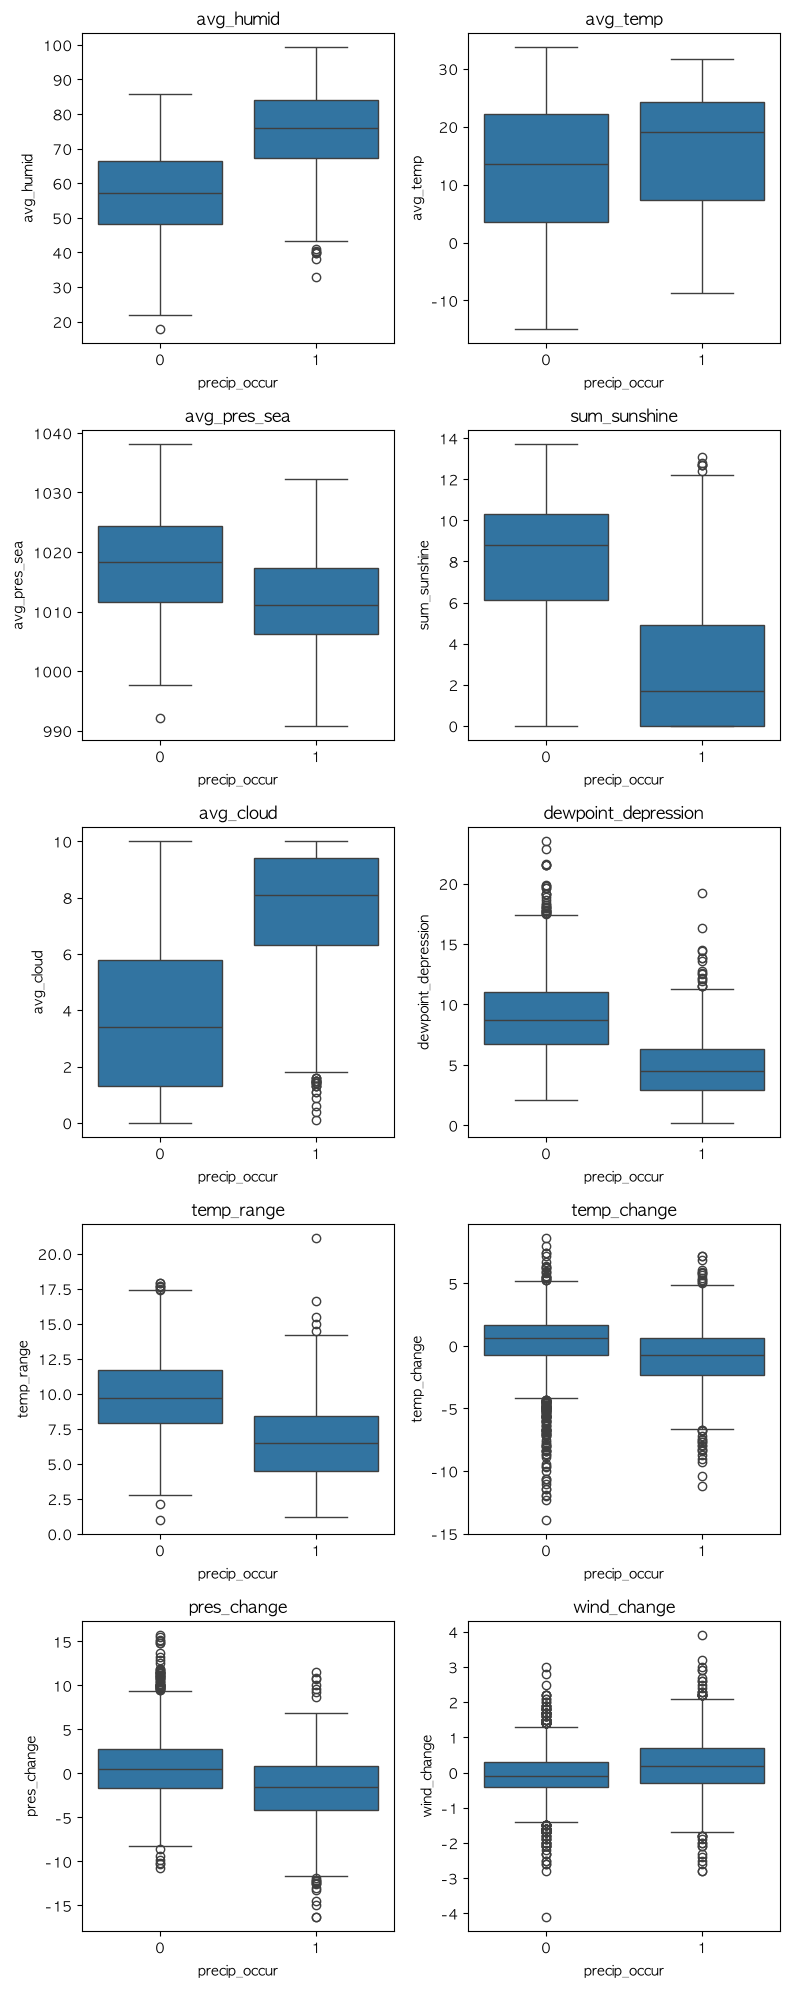

In [349]:
check_cols = ['avg_humid', 'avg_temp', 'avg_pres_sea', 'sum_sunshine', 'avg_cloud',
              'dewpoint_depression', 'temp_range', 'temp_change', 'pres_change', 'wind_change']

fig, axes = plt.subplots(5, 2, figsize=(8, 20))
for ax, col in zip(axes.flat, check_cols):
    sns.boxplot(x='precip_occur', y=col, data=df_merged, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

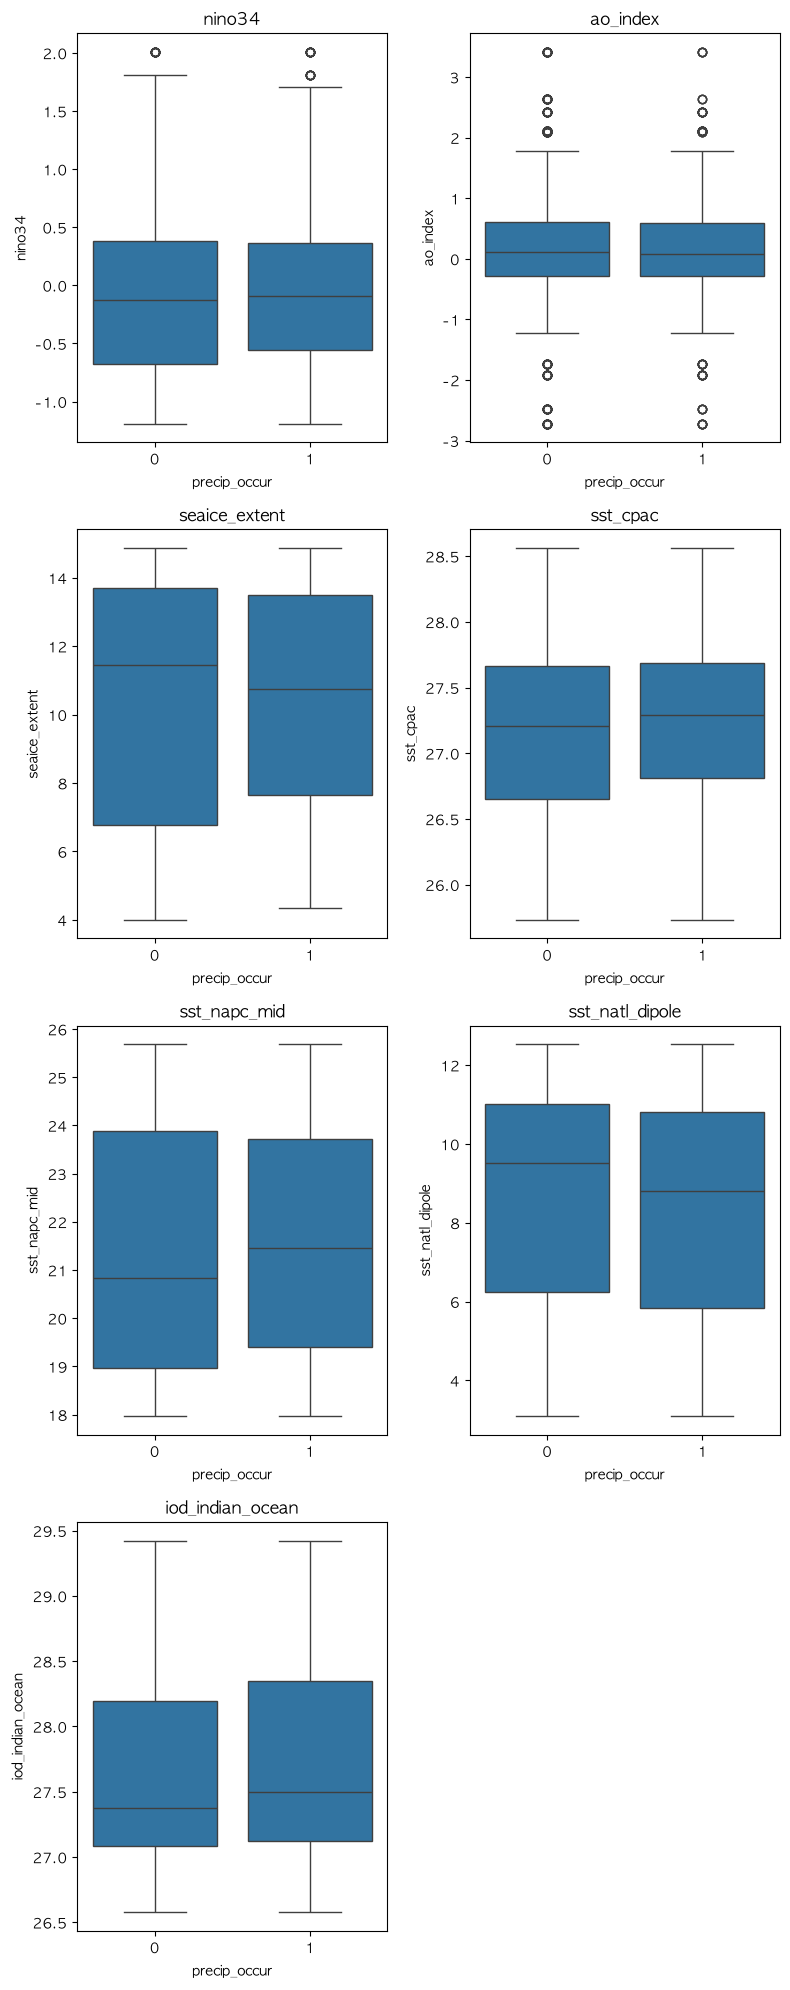

In [350]:
climate_cols = ['nino34', 'ao_index', 'seaice_extent', 'sst_cpac',
                 'sst_napc_mid', 'sst_natl_dipole', 'iod_indian_ocean']

fig, axes = plt.subplots(4, 2, figsize=(8, 20))
for ax, col in zip(axes.flat, climate_cols):
    sns.boxplot(x='precip_occur', y=col, data=df_merged, ax=ax)
    ax.set_title(col)

# 8번째 칸은 비니까 숨기기
axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

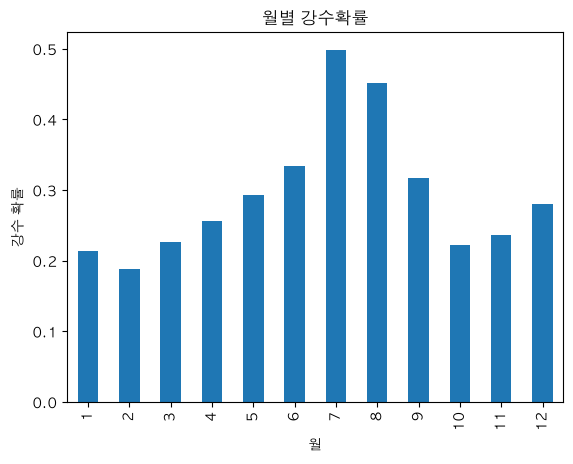

In [351]:
df_merged['month'] = df_merged['date'].dt.month
df_merged.groupby('month')['precip_occur'].mean().plot(kind='bar')
plt.title('월별 강수확률')
plt.xlabel('월')
plt.ylabel('강수 확률')
plt.show()

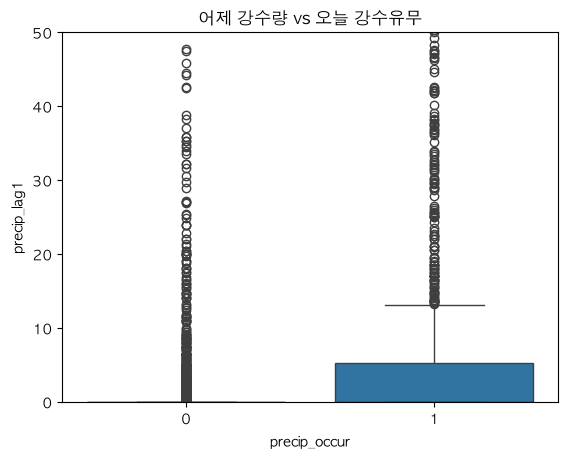

In [352]:
df_merged['precip_lag1'] = df_merged['precip'].shift(1)

sns.boxplot(x='precip_occur', y='precip_lag1', data=df_merged)
plt.title('어제 강수량 vs 오늘 강수유무')
plt.ylim(0, 50)
plt.show()

In [353]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 3659 entries, 0 to 3658
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   stn_id                     3659 non-null   int64         
 1   stn_name                   3659 non-null   str           
 2   date                       3659 non-null   datetime64[us]
 3   avg_temp                   3659 non-null   float64       
 4   min_temp                   3658 non-null   float64       
 5   max_temp                   3658 non-null   float64       
 6   precip                     3659 non-null   float64       
 7   avg_wind                   3651 non-null   float64       
 8   max_wind_dir               3652 non-null   float64       
 9   avg_dewpoint               3659 non-null   float64       
 10  avg_humid                  3659 non-null   float64       
 11  avg_pres_sea               3658 non-null   float64       
 12  sum_sunshine     

In [354]:
asos_cols = ['avg_wind', 'avg_humid', 'avg_pres_sea', 'sum_sunshine', 'avg_cloud']

for col in asos_cols:
    df_merged[f'{col}_lag1'] = df_merged[col].shift(1)

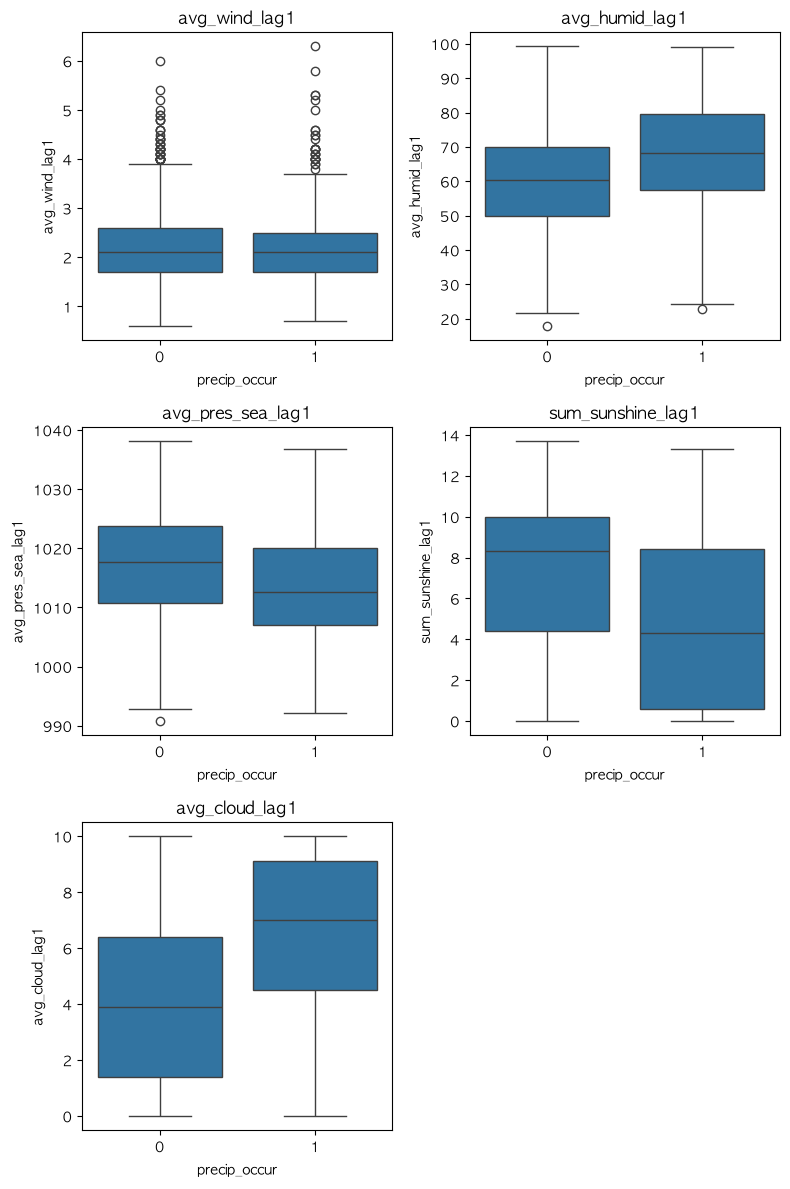

In [355]:

lag_cols = [f'{col}_lag1' for col in asos_cols]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for ax, col in zip(axes.flat, lag_cols):
    sns.boxplot(x='precip_occur', y=col, data=df_merged, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

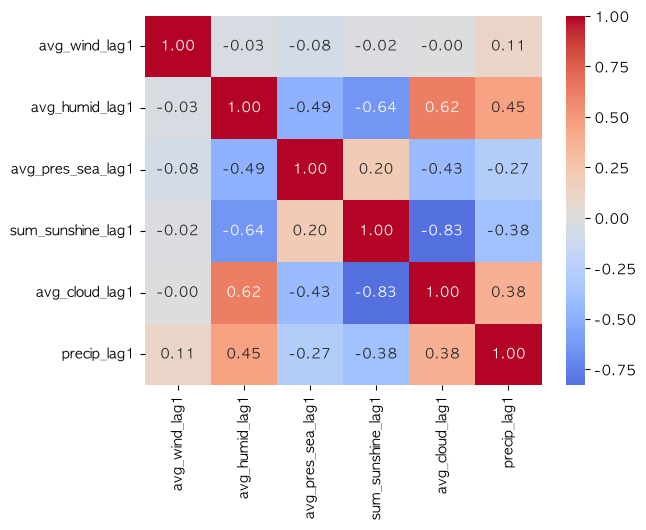

In [356]:
sns.heatmap(df_merged[lag_cols + ['precip_lag1']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.show()

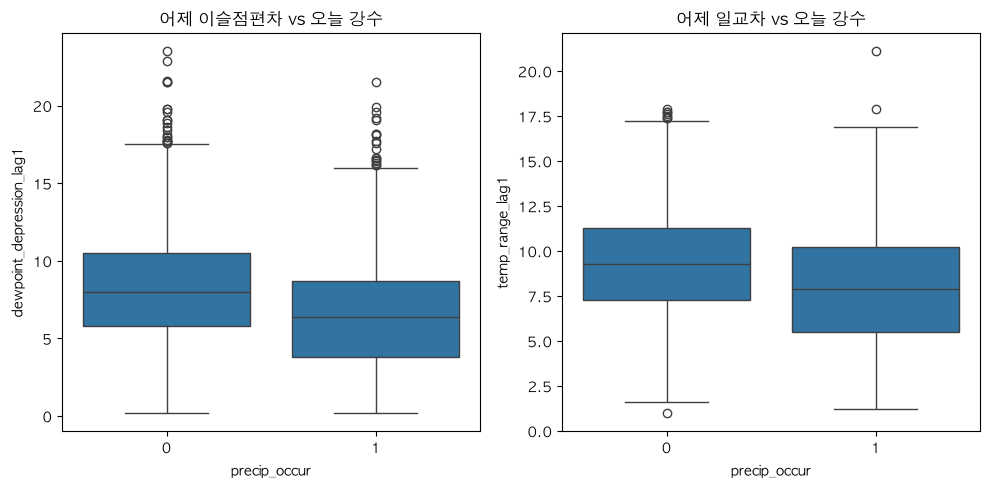

In [357]:
df_merged['dewpoint_depression'] = df_merged['avg_temp'] - df_merged['avg_dewpoint']
df_merged['temp_range'] = df_merged['max_temp'] - df_merged['min_temp']

df_merged['dewpoint_depression_lag1'] = df_merged['dewpoint_depression'].shift(1)
df_merged['temp_range_lag1'] = df_merged['temp_range'].shift(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(x='precip_occur', y='dewpoint_depression_lag1', data=df_merged, ax=axes[0])
axes[0].set_title('어제 이슬점편차 vs 오늘 강수')
sns.boxplot(x='precip_occur', y='temp_range_lag1', data=df_merged, ax=axes[1])
axes[1].set_title('어제 일교차 vs 오늘 강수')
plt.tight_layout()
plt.show()

In [358]:
df_ao = pd.read_csv("data/ao_index.csv")
df_ao['date'] = pd.to_datetime(df_ao['date'])
df_ao = df_ao.set_index('date')

full_dates = pd.date_range(df_ao.index.min(), '2026-12-01', freq='MS')
df_ao = df_ao.reindex(full_dates)
df_ao.index.name = 'date'
df_ao = df_ao.reset_index()

df_ao.isna().sum()

date         0
year        12
month       12
ao_index    12
dtype: int64

In [359]:
import numpy as np

df_test = df_merged[df_merged['nino34'].notna()][['date', 'nino34']].copy()
df_test['month'] = df_test['date'].dt.month

climatology = df_test.groupby('month')['nino34'].mean()

df_test['ffill_pred'] = df_test['nino34'].shift(1)
df_test['clim_pred'] = df_test['month'].map(climatology)

df_test['ffill_error'] = (df_test['nino34'] - df_test['ffill_pred']).abs()
df_test['clim_error'] = (df_test['nino34'] - df_test['clim_pred']).abs()

print("ffill 평균 오차:", df_test['ffill_error'].mean().round(3))
print("동월평균 평균 오차:", df_test['clim_error'].mean().round(3))

ffill 평균 오차: 0.007
동월평균 평균 오차: 0.548


In [360]:
df_merged['min_temp'] = df_merged['min_temp'].interpolate()
df_merged['max_temp'] = df_merged['max_temp'].interpolate()
df_merged['avg_pres_sea'] = df_merged['avg_pres_sea'].interpolate()

df_merged[['min_temp','max_temp','avg_pres_sea']].isna().sum()

min_temp        0
max_temp        0
avg_pres_sea    0
dtype: int64

In [361]:
df_merged['temp_range'] = df_merged['max_temp'] - df_merged['min_temp']

df_merged['temp_range'].isna().sum()

np.int64(0)

In [362]:
df_merged['month_num'] = df_merged['date'].dt.month

for col in ['sst_natl_south', 'sst_natl_north']:
    monthly_avg = df_merged.groupby('month_num')[col].transform('mean')
    df_merged[col] = df_merged[col].fillna(monthly_avg)

df_merged[['sst_natl_south', 'sst_natl_north']].isna().sum()

sst_natl_south    0
sst_natl_north    0
dtype: int64

In [363]:
df_merged['sst_natl_dipole'] = df_merged['sst_natl_south'] - df_merged['sst_natl_north']
df_merged['sst_natl_dipole'].isna().sum()

np.int64(0)

In [364]:
df_merged = df_merged.rename(columns={'sst_napc_mid': 'sst_npac_mid'})
climatology_cols = ['sst_npac_mid', 'ao_index', 'iod_indian_ocean']

In [365]:
climatology_cols = ['sst_npac_mid', 'ao_index', 'iod_indian_ocean']

for col in climatology_cols:
    monthly_avg = df_merged.groupby('month_num')[col].transform('mean')
    df_merged[col] = df_merged[col].fillna(monthly_avg)

df_merged[climatology_cols].isna().sum()

sst_npac_mid        0
ao_index            0
iod_indian_ocean    0
dtype: int64

In [366]:
df_merged = df_merged.drop(columns='month_num')

In [367]:
df_merged['nino34'] = df_merged['nino34'].ffill()
df_merged['sst_cpac'] = df_merged['sst_cpac'].ffill()

df_merged = df_merged.dropna(subset=['avg_wind', 'max_wind_dir'])
df_merged[['nino34', 'sst_cpac', 'avg_wind', 'max_wind_dir']].isna().sum()

nino34          0
sst_cpac        0
avg_wind        0
max_wind_dir    0
dtype: int64

In [368]:
df_merged = df_merged.drop(columns=['sum_sunshine', 'sum_sunshine_lag1'])

In [369]:
df_merged[df_merged['temp_change'].isna()]

,stn_id,stn_name,date,avg_temp,min_temp,max_temp,precip,avg_wind,max_wind_dir,avg_dewpoint,...,wind_change,sst_natl_dipole,month,precip_lag1,avg_wind_lag1,avg_humid_lag1,avg_pres_sea_lag1,avg_cloud_lag1,dewpoint_depression_lag1,temp_range_lag1
0,108,서울,2016-07-01,24.0,22.0,26.6,108.5,2.3,200.0,21.4,...,NaN,9.163,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [370]:
df_merged = df_merged.dropna()
df_merged.isna().sum().sum() 


np.int64(0)

In [371]:
na_summary = df_merged.isna().sum()
na_summary = na_summary[na_summary > 0]

if len(na_summary) == 0:
    print("결측치 없음")
else:
    print("결측치:")
    print(na_summary)

결측치 없음


In [372]:
import numpy as np

df_test = df_merged[df_merged['sst_cpac'].notna()][['date', 'sst_cpac']].copy()
df_test['month'] = df_test['date'].dt.month

climatology = df_test.groupby('month')['sst_cpac'].mean()

df_test['ffill_pred'] = df_test['sst_cpac'].shift(1)
df_test['clim_pred'] = df_test['month'].map(climatology)

df_test['ffill_error'] = (df_test['sst_cpac'] - df_test['ffill_pred']).abs()
df_test['clim_error'] = (df_test['sst_cpac'] - df_test['clim_pred']).abs()

print("ffill 평균 오차:", df_test['ffill_error'].mean().round(3))
print("동월평균 평균 오차:", df_test['clim_error'].mean().round(3))

ffill 평균 오차: 0.008
동월평균 평균 오차: 0.416


In [373]:
import pandas as pd

# 원본 다시 불러오기 (건드린 적 없는 순수 원본)
raw = pd.read_csv("data/kma_2016_2026.csv", encoding='utf-8-sig')
raw['date'] = pd.to_datetime(raw['date'])

# 확인하고 싶은 컬럼의 원래 결측 날짜 추출
target_col = 'avg_pres_sea'  # 원하는 컬럼으로 바꿔도 됨
missing_dates = raw.loc[raw[target_col].isna(), 'date']
print(missing_dates)

1534   2020-09-12
Name: date, dtype: datetime64[us]


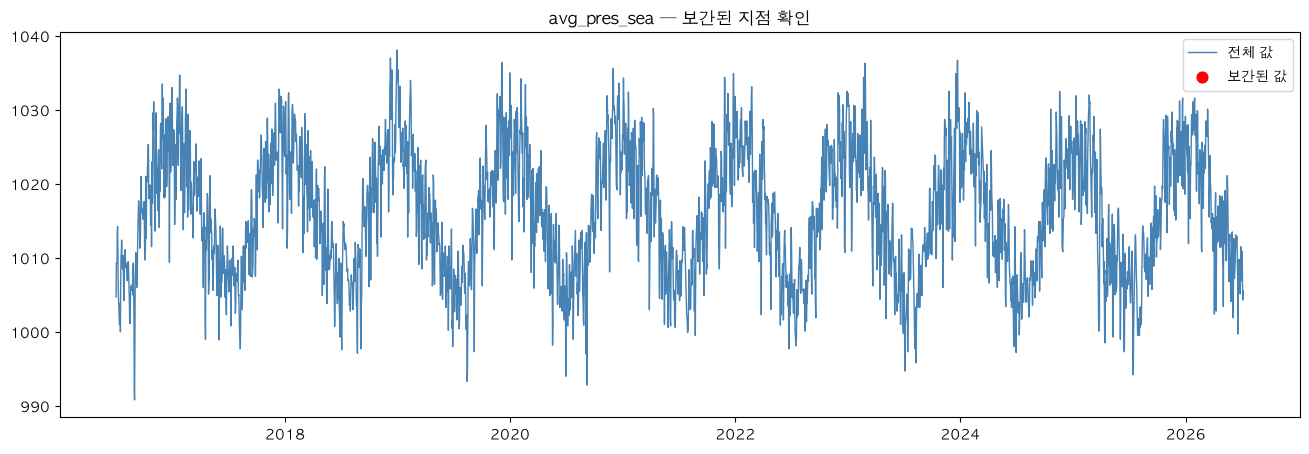

In [374]:
plt.figure(figsize=(16, 5))
plt.plot(df_merged['date'], df_merged['avg_pres_sea'], color='steelblue', linewidth=1, label='전체 값')

plot_df = df_merged[df_merged['date'].isin(missing_dates)]
plt.scatter(plot_df['date'], plot_df['avg_pres_sea'], color='red', s=60, zorder=5, label='보간된 값')

plt.title('avg_pres_sea — 보간된 지점 확인')
plt.legend()
plt.show()

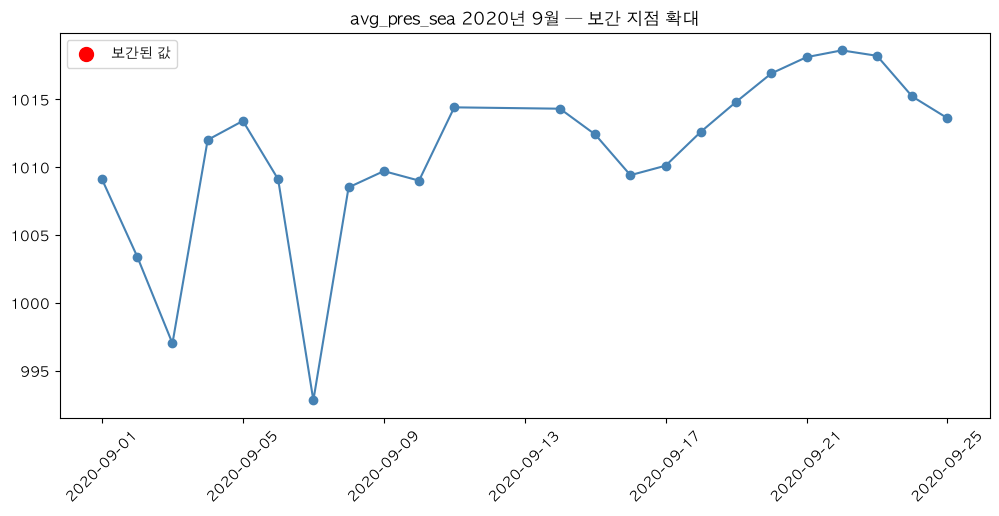

In [375]:
window = df_merged[(df_merged['date'] >= '2020-09-01') & (df_merged['date'] <= '2020-09-25')]

plt.figure(figsize=(12, 5))
plt.plot(window['date'], window['avg_pres_sea'], marker='o', color='steelblue', linewidth=1.5)

plot_df = window[window['date'].isin(missing_dates)]
plt.scatter(plot_df['date'], plot_df['avg_pres_sea'], color='red', s=100, zorder=5, label='보간된 값')

plt.title('avg_pres_sea 2020년 9월 — 보간 지점 확대')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [376]:
missing_dates_normalized = pd.to_datetime(missing_dates).dt.normalize()
df_dates_normalized = df_merged['date'].dt.normalize()

plot_df = df_merged[df_dates_normalized.isin(missing_dates_normalized)]
print(plot_df)  # 여기서 뭔가 나와야 함

Empty DataFrame
Columns: [stn_id, stn_name, date, avg_temp, min_temp, max_temp, precip, avg_wind, max_wind_dir, avg_dewpoint, avg_humid, avg_pres_sea, avg_cloud, precip_occur, nino34, nino34_lag_days, ao_index, ao_index_lag_days, seaice_extent, seaice_extent_lag_days, sst_cpac, sst_cpac_lag_days, sst_npac_mid, sst_napc_mid_lag_days, sst_natl_north, sst_natl_north_lag_days, sst_natl_south, sst_natl_south_lag_days, iod_indian_ocean, iod_indian_ocean_lag_days, dewpoint_depression, temp_range, temp_change, pres_change, wind_change, sst_natl_dipole, month, precip_lag1, avg_wind_lag1, avg_humid_lag1, avg_pres_sea_lag1, avg_cloud_lag1, dewpoint_depression_lag1, temp_range_lag1]
Index: []

[0 rows x 44 columns]


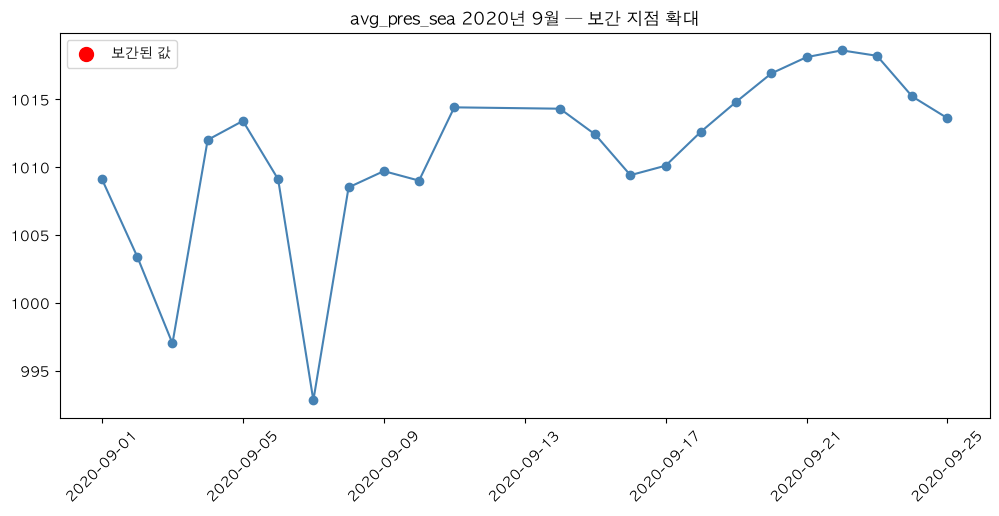

In [377]:
plt.figure(figsize=(12, 5))
plt.plot(window['date'], window['avg_pres_sea'], marker='o', color='steelblue', linewidth=1.5)

plot_df = window[window['date'].dt.normalize().isin(missing_dates_normalized)]
plt.scatter(plot_df['date'], plot_df['avg_pres_sea'], color='red', s=100, zorder=5, label='보간된 값')

plt.title('avg_pres_sea 2020년 9월 — 보간 지점 확대')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [378]:
print('2020-09-12' in df_merged['date'].dt.strftime('%Y-%m-%d').values)

False


In [379]:
raw['min_temp']
missing_dates_temp = raw.loc[raw['min_temp'].isna(), 'date']
print(missing_dates_temp)

missing_norm = pd.to_datetime(missing_dates_temp).dt.normalize()
check = df_merged[df_merged['date'].dt.normalize().isin(missing_norm)]
print(check[['date', 'min_temp']])

2229   2022-08-08
Name: date, dtype: datetime64[us]
           date  min_temp
2229 2022-08-08      24.6


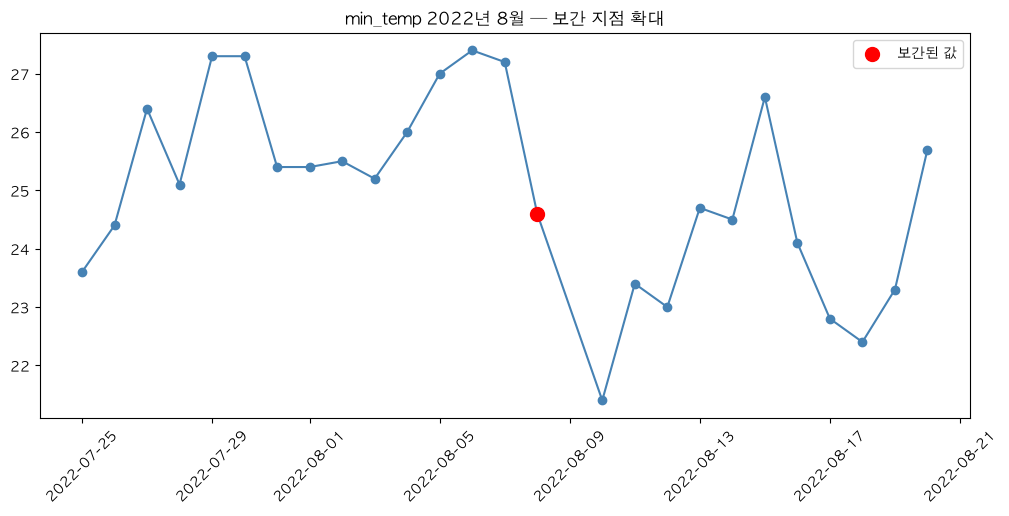

In [380]:
window = df_merged[(df_merged['date'] >= '2022-07-25') & (df_merged['date'] <= '2022-08-20')]

plt.figure(figsize=(12, 5))
plt.plot(window['date'], window['min_temp'], marker='o', color='steelblue', linewidth=1.5)

plot_df = window[window['date'].dt.normalize().isin(missing_norm)]
plt.scatter(plot_df['date'], plot_df['min_temp'], color='red', s=100, zorder=5, label='보간된 값')

plt.title('min_temp 2022년 8월 — 보간 지점 확대')
plt.xticks(rotation=45)
plt.legend()
plt.show()

마지막 실측값 날짜: 2026-04-01 00:00:00


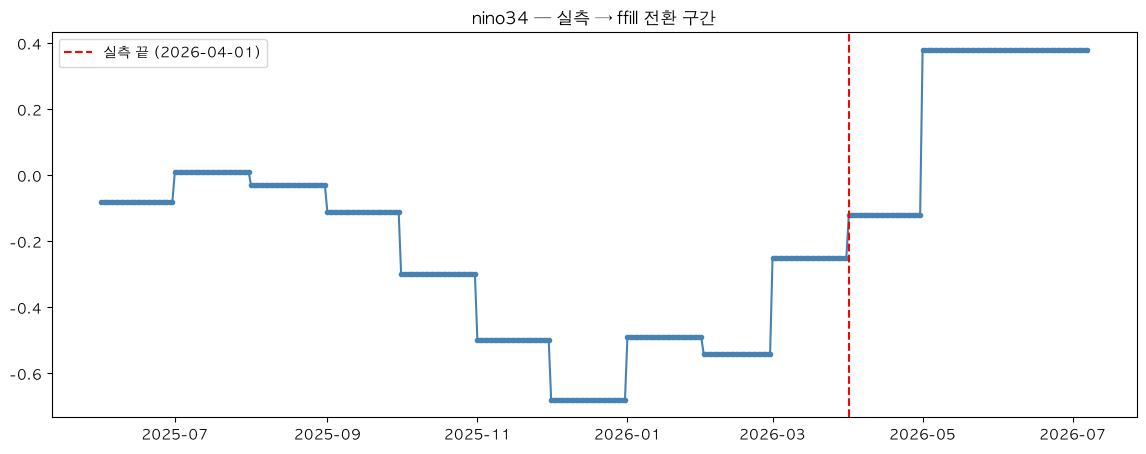

In [381]:
raw_nino = pd.read_csv("data/nino34.csv", encoding='utf-8-sig')
raw_nino['date'] = pd.to_datetime(raw_nino['date'])
last_real_date = raw_nino.loc[raw_nino['nino34'] > -900, 'date'].max()
print("마지막 실측값 날짜:", last_real_date)

window = df_merged[df_merged['date'] >= '2025-06-01']

plt.figure(figsize=(14, 5))
plt.plot(window['date'], window['nino34'], marker='o', markersize=3, color='steelblue')
plt.axvline(last_real_date, color='red', linestyle='--', label=f'실측 끝 ({last_real_date.date()})')
plt.title('nino34 — 실측 → ffill 전환 구간')
plt.legend()
plt.show()

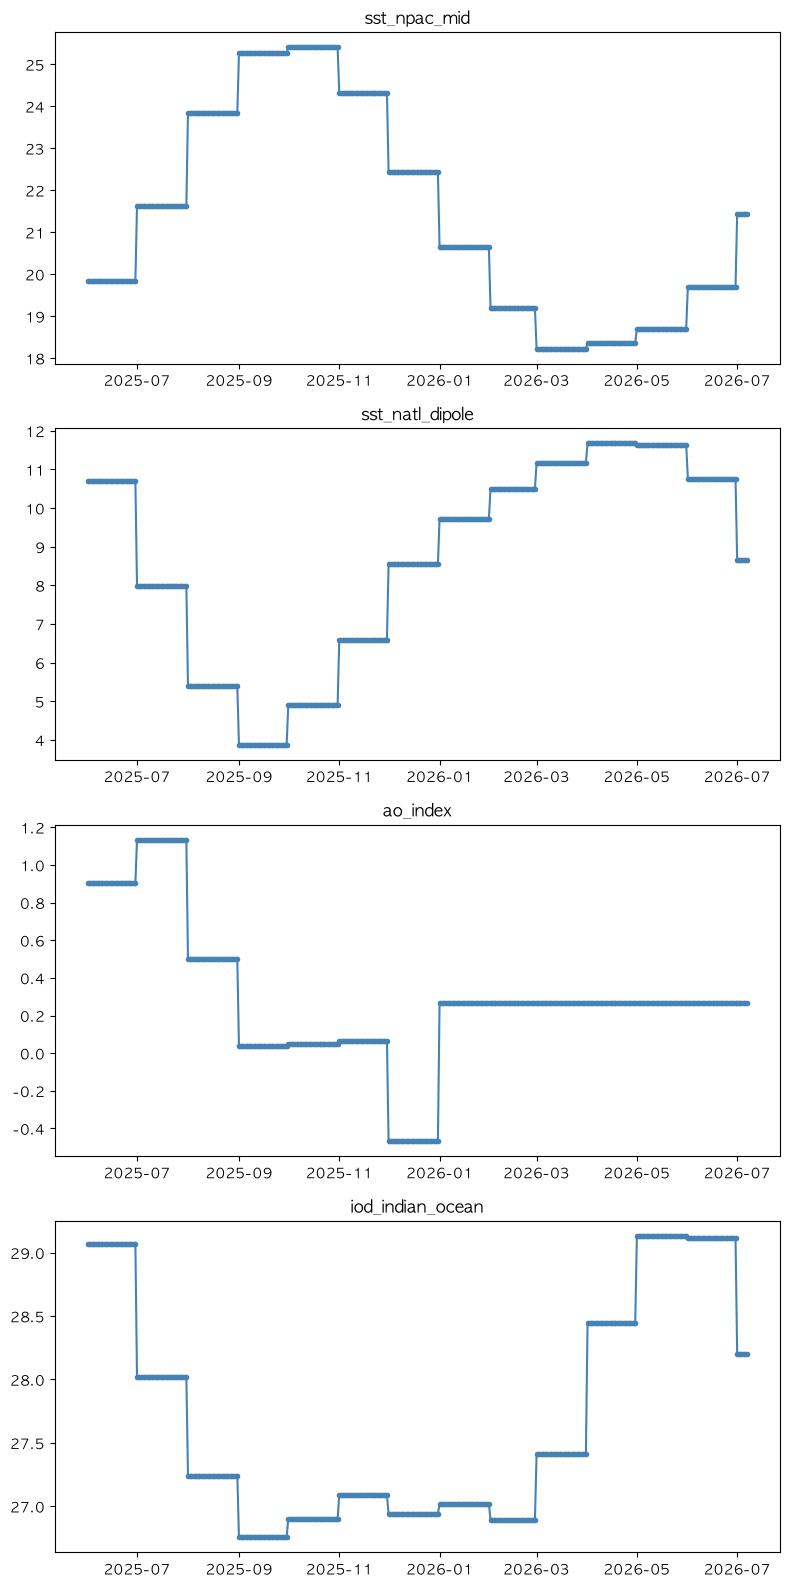

In [382]:
climatology_indices = ['sst_npac_mid', 'sst_natl_dipole', 'ao_index', 'iod_indian_ocean']

fig, axes = plt.subplots(4, 1, figsize=(8, 16))
for ax, col in zip(axes.flat, climatology_indices):
    ax.plot(window['date'], window[col], marker='o', markersize=3, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [383]:
cols_check = ['date', 'sst_npac_mid', 'sst_natl_dipole', 'ao_index', 'iod_indian_ocean', 'nino34']
print(df_merged[cols_check].tail(15))

           date  sst_npac_mid  sst_natl_dipole  ao_index  iod_indian_ocean  \
3644 2026-06-23     19.696111        10.764444     0.267         29.116444   
3645 2026-06-24     19.696111        10.764444     0.267         29.116444   
3646 2026-06-25     19.696111        10.764444     0.267         29.116444   
3647 2026-06-26     19.696111        10.764444     0.267         29.116444   
3648 2026-06-27     19.696111        10.764444     0.267         29.116444   
3649 2026-06-28     19.696111        10.764444     0.267         29.116444   
3650 2026-06-29     19.696111        10.764444     0.267         29.116444   
3651 2026-06-30     19.696111        10.764444     0.267         29.116444   
3652 2026-07-01     21.442900         8.650500     0.267         28.204400   
3653 2026-07-02     21.442900         8.650500     0.267         28.204400   
3654 2026-07-03     21.442900         8.650500     0.267         28.204400   
3655 2026-07-04     21.442900         8.650500     0.267        

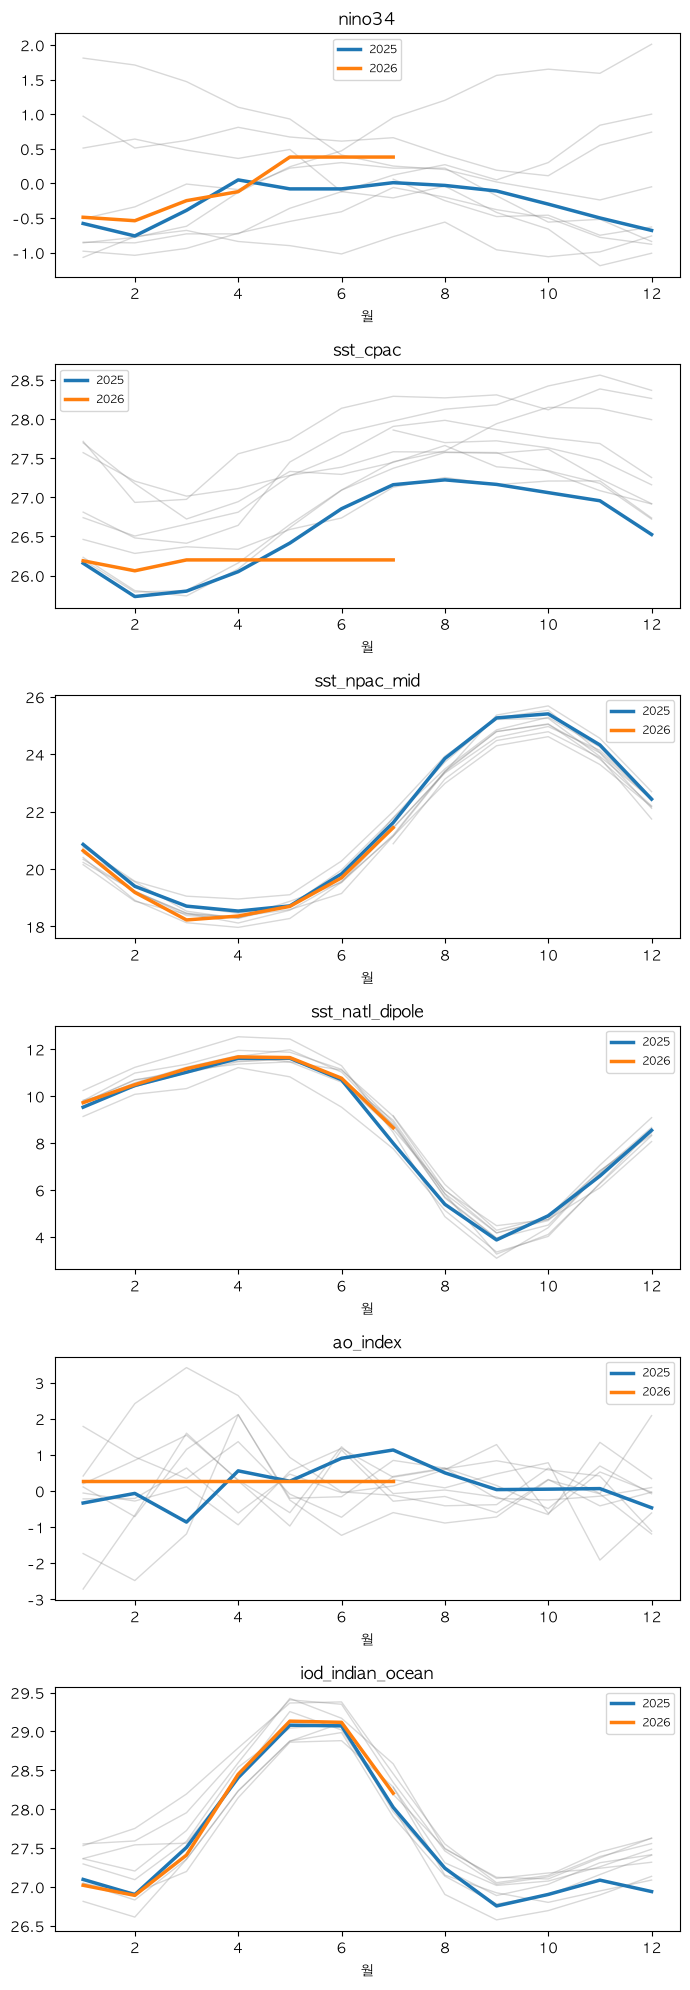

In [384]:
indices_to_check = ['nino34', 'sst_cpac', 'sst_npac_mid', 'sst_natl_dipole', 'ao_index', 'iod_indian_ocean']

df_merged['month'] = df_merged['date'].dt.month
df_merged['year'] = df_merged['date'].dt.year

fig, axes = plt.subplots(6, 1, figsize=(7, 20))
for ax, col in zip(axes.flat, indices_to_check):
    for yr in sorted(df_merged['year'].unique()):
        yearly = df_merged[df_merged['year'] == yr].groupby('month')[col].mean()
        # 최근 2개 연도만 강조, 나머지는 흐리게
        if yr >= 2025:
            ax.plot(yearly.index, yearly.values, label=str(yr), linewidth=2.5, zorder=5)
        else:
            ax.plot(yearly.index, yearly.values, color='gray', alpha=0.3, linewidth=1)
    ax.set_title(col)
    ax.set_xlabel('월')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

총 확인할 지점: 3개
  min_temp: 2022-08-08
  max_temp: 2017-10-12
  avg_pres_sea: 2020-09-12


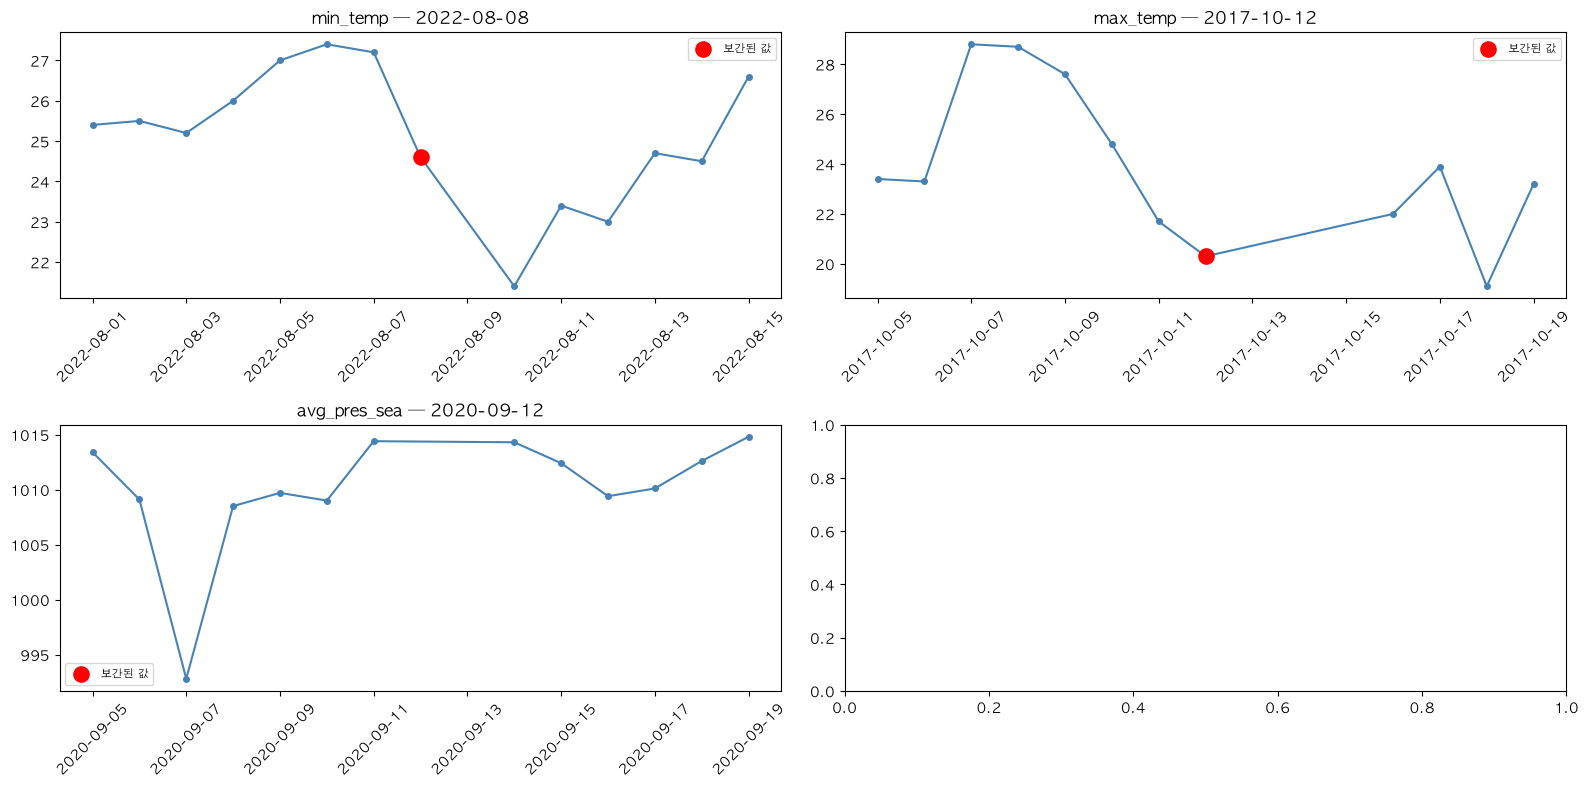

In [385]:
raw = pd.read_csv("data/kma_2016_2026.csv", encoding='utf-8-sig')
raw['date'] = pd.to_datetime(raw['date'])

# 선형보간한 컬럼들 (temp_range는 min_temp/max_temp 기준으로 확인)
check_map = {
    'min_temp': 'min_temp',
    'max_temp': 'max_temp',
    'avg_pres_sea': 'avg_pres_sea',
}

# 각 컬럼의 결측 날짜 다 모으기
all_missing = []
for col in check_map:
    dates = raw.loc[raw[col].isna(), 'date'].tolist()
    for d in dates:
        all_missing.append((col, d))

print(f"총 확인할 지점: {len(all_missing)}개")
for col, d in all_missing:
    print(f"  {col}: {d.date()}")

# 격자로 한 번에 시각화
n = len(all_missing)
fig, axes = plt.subplots((n+1)//2, 2, figsize=(16, 4*((n+1)//2)))
axes = axes.flat if n > 1 else [axes]

for ax, (col, missing_date) in zip(axes, all_missing):
    start = missing_date - pd.Timedelta(days=7)
    end = missing_date + pd.Timedelta(days=7)
    window = df_merged[(df_merged['date'] >= start) & (df_merged['date'] <= end)]

    ax.plot(window['date'], window[col], marker='o', markersize=4, color='steelblue')
    highlight = window[window['date'] == missing_date]
    ax.scatter(highlight['date'], highlight[col], color='red', s=120, zorder=5, label='보간된 값')
    ax.set_title(f"{col} — {missing_date.date()}")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [386]:
for col in ['nino34', 'sst_cpac', 'ao_index', 'sst_npac_mid', 'iod_indian_ocean']:
    s = df_merged.sort_values('date').set_index('date')[col]
    last_val = s.iloc[-1]
    changed = s[s != last_val]
    if len(changed) > 0:
        print(f"{col}: {changed.index.max().date()} 이후로 {last_val} 고정")
    else:
        print(f"{col}: 전 구간이 같은 값 (뭔가 이상함)")

nino34: 2026-04-30 이후로 0.38 고정
sst_cpac: 2026-02-28 이후로 26.2 고정
ao_index: 2025-12-31 이후로 0.267 고정
sst_npac_mid: 2026-06-30 이후로 21.4429 고정
iod_indian_ocean: 2026-06-30 이후로 28.2044 고정


In [387]:
df_merged.loc[df_merged['date'] > '2025-12-31', 'ao_index'] = None

actual_ao = {1: -2.048, 2: -1.256, 3: 2.044, 4: 0.254}
for m, val in actual_ao.items():
    mask = (df_merged['date'].dt.year == 2026) & (df_merged['date'].dt.month == m)
    df_merged.loc[mask, 'ao_index'] = val

df_merged['month_num'] = df_merged['date'].dt.month
monthly_avg = df_merged.groupby('month_num')['ao_index'].transform('mean')
df_merged['ao_index'] = df_merged['ao_index'].fillna(monthly_avg)

mask = df_merged['date'] >= '2026-01-01'
print(df_merged.loc[mask, ['date', 'ao_index']].drop_duplicates('ao_index'))

           date  ao_index
3471 2026-01-01 -2.048000
3502 2026-02-01 -1.256000
3530 2026-03-01  2.044000
3561 2026-04-01  0.254000
3591 2026-05-01  0.009000
3622 2026-06-01  0.249444
3652 2026-07-01  0.212375


In [388]:
# 리셋 → 실측 주입 (이번엔 6월까지) → 나머지(7월)만 동월 평균
df_merged.loc[df_merged['date'] > '2025-12-31', 'ao_index'] = None

actual_ao = {1: -2.048, 2: -1.256, 3: 2.044, 4: 0.254, 5: 0.545, 6: 0.660}
for m, val in actual_ao.items():
    mask = (df_merged['date'].dt.year == 2026) & (df_merged['date'].dt.month == m)
    df_merged.loc[mask, 'ao_index'] = val

monthly_avg = df_merged.groupby('month_num')['ao_index'].transform('mean')
df_merged['ao_index'] = df_merged['ao_index'].fillna(monthly_avg)

mask = df_merged['date'] >= '2026-01-01'
print(df_merged.loc[mask, ['date', 'ao_index']].drop_duplicates('ao_index'))

           date  ao_index
3471 2026-01-01 -2.048000
3502 2026-02-01 -1.256000
3530 2026-03-01  2.044000
3561 2026-04-01  0.254000
3591 2026-05-01  0.545000
3622 2026-06-01  0.660000
3652 2026-07-01  0.212375


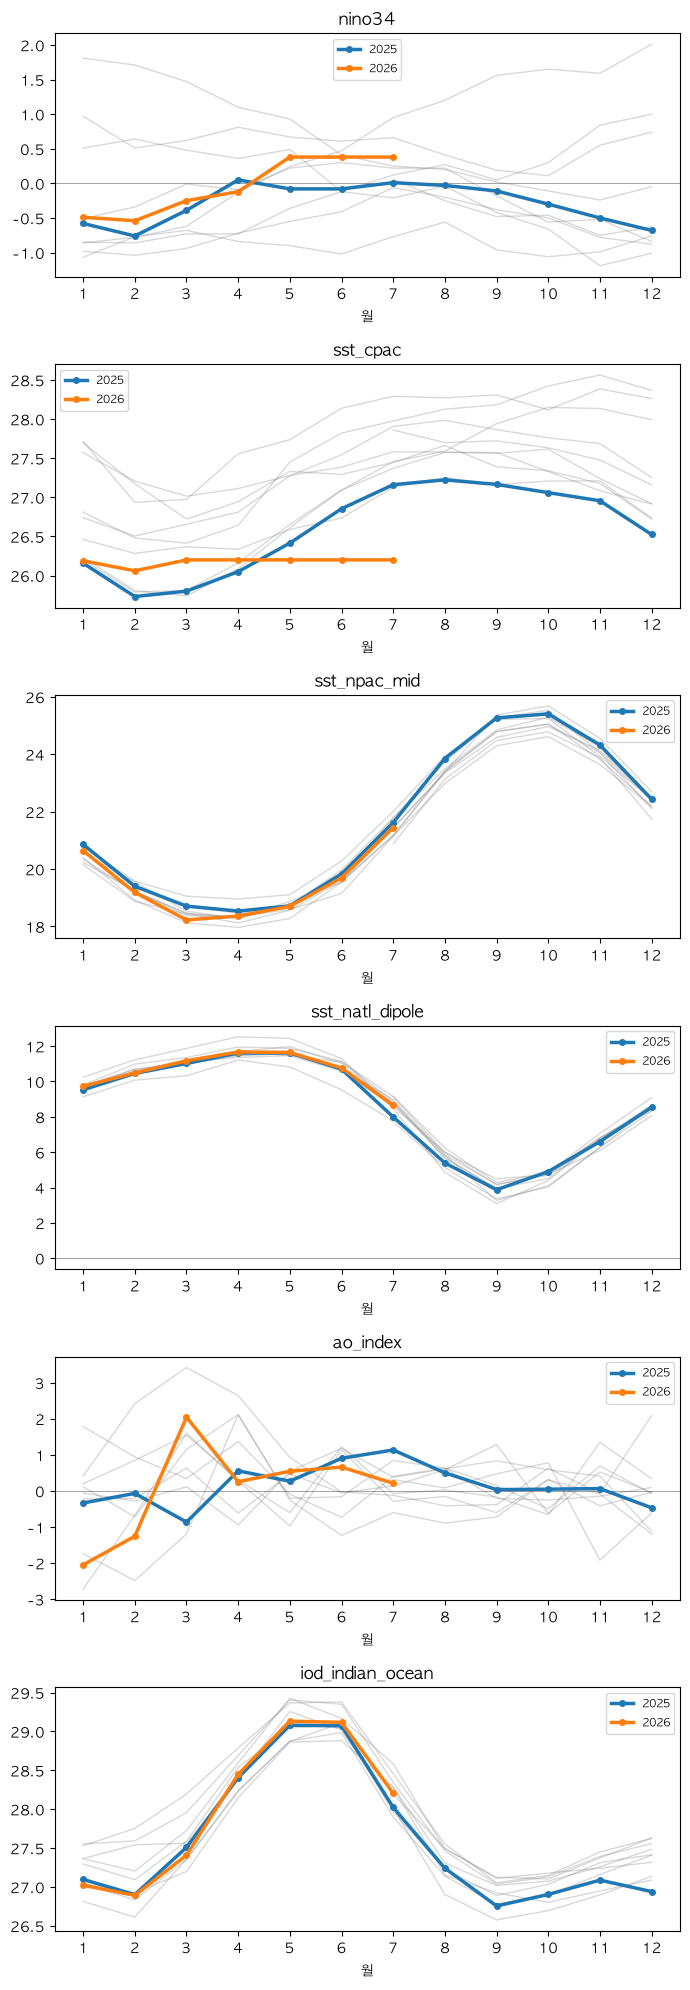

In [389]:
anomaly_cols = {'nino34', 'ao_index', 'sst_natl_dipole'}  # 0이 기준인 지수들

fig, axes = plt.subplots(6, 1, figsize=(7, 20))
for ax, col in zip(axes.flat, indices_to_check):
    for yr in sorted(df_merged['year'].unique()):
        yearly = df_merged[df_merged['year'] == yr].groupby('month')[col].mean()
        if yr >= 2025:
            ax.plot(yearly.index, yearly.values, label=str(yr),
                    linewidth=2.5, zorder=5, marker='o', markersize=4)
        else:
            ax.plot(yearly.index, yearly.values, color='gray',
                    alpha=0.3, linewidth=1)
    if col in anomaly_cols:
        ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_xticks(range(1, 13))
    ax.set_title(col)
    ax.set_xlabel('월')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [390]:
# sst_cpac: 3월 이후 가짜 값 리셋 → 동월 평균으로 채우기
df_merged.loc[df_merged['date'] > '2026-02-28', 'sst_cpac'] = None
monthly_avg = df_merged.groupby('month_num')['sst_cpac'].transform('mean')
df_merged['sst_cpac'] = df_merged['sst_cpac'].fillna(monthly_avg)

# 확인 — 3월부터 달마다 다른 값(역대 월평균)이 나와야 함
mask = df_merged['date'] >= '2026-01-01'
print(df_merged.loc[mask, ['date', 'sst_cpac']].drop_duplicates('sst_cpac'))

           date   sst_cpac
3471 2026-01-01  26.189000
3502 2026-02-01  26.061000
3530 2026-03-01  26.377464
3561 2026-04-01  26.632889
3591 2026-05-01  27.038111
3622 2026-06-01  27.328333
3652 2026-07-01  27.616816


In [391]:
df_merged.loc[df_merged['date'] > '2026-04-30', 'nino34'] = None
monthly_avg = df_merged.groupby('month_num')['nino34'].transform('mean')
df_merged['nino34'] = df_merged['nino34'].fillna(monthly_avg)

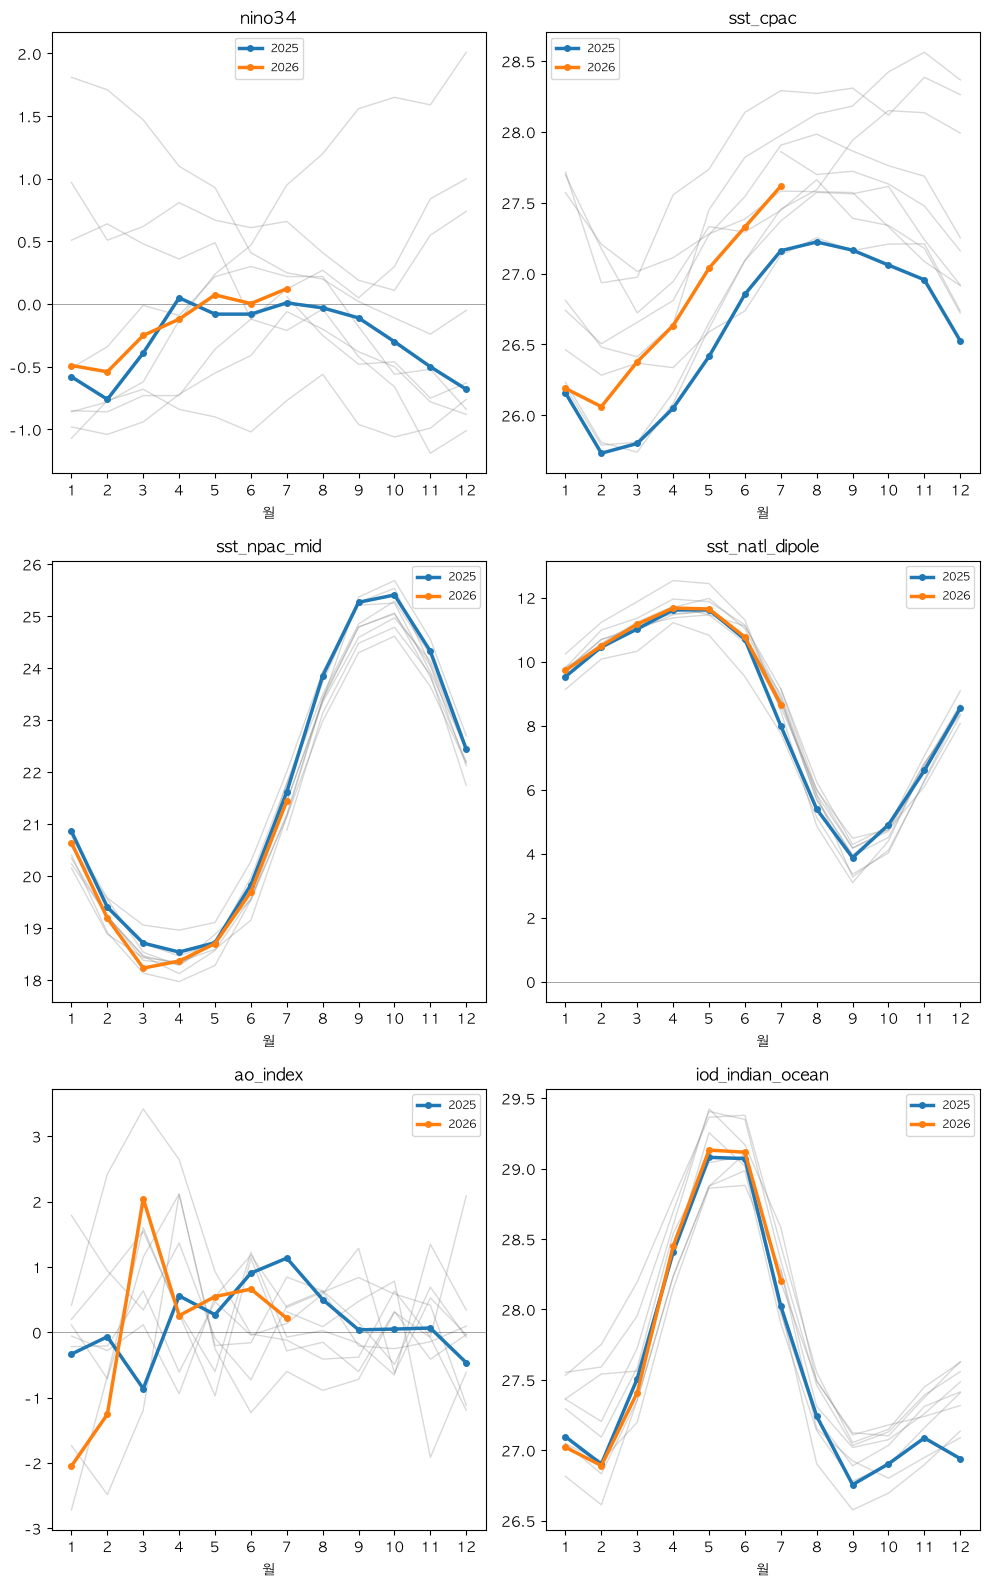

In [392]:
anomaly_cols = {'nino34', 'ao_index', 'sst_natl_dipole'}  # 0이 기준인 지수들

fig, axes = plt.subplots(3, 2, figsize=(10, 16))
for ax, col in zip(axes.flat, indices_to_check):
    for yr in sorted(df_merged['year'].unique()):
        yearly = df_merged[df_merged['year'] == yr].groupby('month')[col].mean()
        if yr >= 2025:
            ax.plot(yearly.index, yearly.values, label=str(yr),
                    linewidth=2.5, zorder=5, marker='o', markersize=4)
        else:
            ax.plot(yearly.index, yearly.values, color='gray',
                    alpha=0.3, linewidth=1)
    if col in anomaly_cols:
        ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_xticks(range(1, 13))
    ax.set_title(col)
    ax.set_xlabel('월')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [393]:
# 시간 기준 분할: 2016-2023 train / 2024-2026 test
train = df_merged[df_merged['date'] < '2024-01-01'].copy()
test  = df_merged[df_merged['date'] >= '2024-01-01'].copy()

print(f"train: {len(train):,}행 ({train['date'].min().date()} ~ {train['date'].max().date()})")
print(f"test:  {len(test):,}행 ({test['date'].min().date()} ~ {test['date'].max().date()})")

# 강수 비율 확인 — train/test가 비슷해야 정상
print(f"\ntrain 강수 비율: {train['precip_occur'].mean():.3f}")
print(f"test  강수 비율: {test['precip_occur'].mean():.3f}")

train: 2,727행 (2016-07-02 ~ 2023-12-31)
test:  914행 (2024-01-01 ~ 2026-07-07)

train 강수 비율: 0.293
test  강수 비율: 0.296


In [394]:
target = 'precip_occur'

# 학습에 쓰면 안 되는 컬럼 제거
drop_cols = [
    target,           # 타깃
    'date',           # 날짜 자체
    'year', 'month', 'month_num', 
    'precip', 'stn_id', 'stn_name'
]

feature_cols = [c for c in train.columns if c not in drop_cols]
print("사용할 피처:")
for c in feature_cols:
    print(f"  - {c}")

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

사용할 피처:
  - avg_temp
  - min_temp
  - max_temp
  - avg_wind
  - max_wind_dir
  - avg_dewpoint
  - avg_humid
  - avg_pres_sea
  - avg_cloud
  - nino34
  - nino34_lag_days
  - ao_index
  - ao_index_lag_days
  - seaice_extent
  - seaice_extent_lag_days
  - sst_cpac
  - sst_cpac_lag_days
  - sst_npac_mid
  - sst_napc_mid_lag_days
  - sst_natl_north
  - sst_natl_north_lag_days
  - sst_natl_south
  - sst_natl_south_lag_days
  - iod_indian_ocean
  - iod_indian_ocean_lag_days
  - dewpoint_depression
  - temp_range
  - temp_change
  - pres_change
  - wind_change
  - sst_natl_dipole
  - precip_lag1
  - avg_wind_lag1
  - avg_humid_lag1
  - avg_pres_sea_lag1
  - avg_cloud_lag1
  - dewpoint_depression_lag1
  - temp_range_lag1


In [395]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ← train에서만 fit
X_test_scaled  = scaler.transform(X_test)        # ← 같은 스케일러로 transform만

import pandas as pd
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

print("train mean:", X_train_scaled.mean().mean().round(3))  # ≈ 0
print("train std: ", X_train_scaled.std().mean().round(3))   # ≈ 1
print("test  mean:", X_test_scaled.mean().mean().round(3))   # 0에 가깝지만 정확히 0은 아님 (정상)
print("test  std: ", X_test_scaled.std().mean().round(3))    # 1 근처 (정상)

train mean: 0.0
train std:  1.0
test  mean: 0.044
test  std:  1.073


In [396]:
print("=== X_train (원본, 스케일링 X) ===")
print(X_train.head(3))
print()
print("=== X_train_scaled (스케일링 O) ===")
print(X_train_scaled.head(3))

=== X_train (원본, 스케일링 X) ===
   avg_temp  min_temp  max_temp  avg_wind  max_wind_dir  avg_dewpoint  \
1      23.5      20.6      27.7       2.4         270.0          19.8   
2      23.5      21.1      26.8       1.6         140.0          17.6   
3      21.8      20.2      24.1       3.0          70.0          19.0   

   avg_humid  avg_pres_sea  avg_cloud  nino34  ...  pres_change  wind_change  \
1       81.4        1004.7        8.0    0.06  ...          0.5          0.1   
2       70.4        1009.3        6.5    0.06  ...          4.6         -0.8   
3       85.1        1009.2        9.1    0.06  ...         -0.1          1.4   

   sst_natl_dipole  precip_lag1  avg_wind_lag1  avg_humid_lag1  \
1            9.163        108.5            2.3            86.5   
2            9.163          4.0            2.4            81.4   
3            9.163          0.0            1.6            70.4   

   avg_pres_sea_lag1  avg_cloud_lag1  dewpoint_depression_lag1  \
1             1004.2      

In [397]:
for c in df_merged.columns:
    print(f"  - {c}")

  - stn_id
  - stn_name
  - date
  - avg_temp
  - min_temp
  - max_temp
  - precip
  - avg_wind
  - max_wind_dir
  - avg_dewpoint
  - avg_humid
  - avg_pres_sea
  - avg_cloud
  - precip_occur
  - nino34
  - nino34_lag_days
  - ao_index
  - ao_index_lag_days
  - seaice_extent
  - seaice_extent_lag_days
  - sst_cpac
  - sst_cpac_lag_days
  - sst_npac_mid
  - sst_napc_mid_lag_days
  - sst_natl_north
  - sst_natl_north_lag_days
  - sst_natl_south
  - sst_natl_south_lag_days
  - iod_indian_ocean
  - iod_indian_ocean_lag_days
  - dewpoint_depression
  - temp_range
  - temp_change
  - pres_change
  - wind_change
  - sst_natl_dipole
  - month
  - precip_lag1
  - avg_wind_lag1
  - avg_humid_lag1
  - avg_pres_sea_lag1
  - avg_cloud_lag1
  - dewpoint_depression_lag1
  - temp_range_lag1
  - year
  - month_num


In [398]:
df_merged['humid_rolling_3d_mean'] = df_merged['avg_humid'].shift(1).rolling(3, min_periods=1).mean()
df_merged['pres_rolling_3d_mean'] = df_merged['avg_pres_sea'].shift(1).rolling(3, min_periods=1).mean()
df_merged['precip_rolling_3d_sum'] = df_merged['precip_occur'].shift(1).rolling(3, min_periods=1).sum()
df_merged['precip_rolling_7d_sum'] = df_merged['precip_occur'].shift(1).rolling(7, min_periods=1).sum()

In [399]:
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12)

In [400]:
new_features = ['humid_rolling_3d_mean', 'pres_rolling_3d_mean', 
                'precip_rolling_3d_sum', 'precip_rolling_7d_sum',
                'month_sin', 'month_cos']
print(df_merged[new_features].head(10))
print(df_merged[new_features].isna().sum())

    humid_rolling_3d_mean  pres_rolling_3d_mean  precip_rolling_3d_sum  \
1                     NaN                   NaN                    NaN   
2               81.400000           1004.700000                    1.0   
3               75.900000           1007.000000                    1.0   
4               78.966667           1007.733333                    2.0   
5               83.033333           1009.300000                    2.0   
6               84.233333           1010.766667                    2.0   
7               79.733333           1012.433333                    1.0   
8               70.700000           1012.500000                    0.0   
9               67.633333           1009.933333                    0.0   
10              65.233333           1006.633333                    0.0   

    precip_rolling_7d_sum  month_sin  month_cos  
1                     NaN       -0.5  -0.866025  
2                     1.0       -0.5  -0.866025  
3                     1.0       -0.

In [401]:
!pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [402]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [403]:
#dummy 평가 지표 (무조건 비 안 온다고 함)

from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score
import numpy as np

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

print("Dummy log_loss:", log_loss(y_test, dummy_preds_proba))
print("Dummy accuracy:", accuracy_score(y_test, dummy.predict(X_test)))
print("Dummy AUC:", roc_auc_score(y_test, dummy_preds_proba))
print("Dummy F1:", f1_score(y_test, dummy.predict(X_test)))

Dummy log_loss: 2.048845735578395
Dummy accuracy: 0.7035010940919038
Dummy AUC: 0.5
Dummy F1: 0.0


In [404]:
#persistence 평가 지표 (무조건 어제랑 똑같다고 함)

persistence_preds = test['precip_occur'].shift(1)
persistence_preds = persistence_preds.bfill()

import numpy as np
persistence_proba = np.clip(persistence_preds, 0.001, 0.999)

print("Persistence log_loss:", log_loss(y_test, persistence_proba))
print("Persistence accuracy:", accuracy_score(y_test, persistence_preds))
print("Persistence AUC:", roc_auc_score(y_test, persistence_proba))
print("Persistence F1:", f1_score(y_test, persistence_preds))

Persistence log_loss: 2.199978225264359
Persistence accuracy: 0.6816192560175055
Persistence AUC: 0.6178745846556444
Persistence F1: 0.46210720887245843


In [405]:
import numpy as np
import pandas as pd
import optuna
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score

tscv = TimeSeriesSplit(n_splits=5)

# 모델 공통 검증 함수 - 하이퍼파라미터 튜닝용(재사용)
def run_cv(model, X_data=X_train):   # 기본값은 X_train, 필요하면 X_train_scaled로 넘김
    scores = []
    for tr_idx, val_idx in tscv.split(X_data):
        X_tr, X_val = X_data.iloc[tr_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(log_loss(y_val, preds))
    return np.mean(scores)


In [406]:
from sklearn.neural_network import MLPClassifier

#MLP 최적 하이퍼파라미터
def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 16, 128) for i in range(n_layers)
    )
    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),  # L2 정규화 강도
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

#MLP 튜닝 값들 중 최고 성능
study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=50)

print("MLP 최적 하이퍼파라미터:")
for k, v in study_mlp.best_params.items():
    print(f"  {k}: {v}")
print(f"MLP 최고 성능(logloss): {study_mlp.best_value:.4f}")

# hidden_layer_sizes 재구성 (best_params엔 n_layers, n_units_l0... 형태로 흩어져 있음)
n_layers = study_mlp.best_params['n_layers']
hidden_sizes = tuple(study_mlp.best_params[f'n_units_l{i}'] for i in range(n_layers))

#최적 하이퍼파라미터로 최종 MLP 모델 생성
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

[I 2026-07-15 10:39:19,286] A new study created in memory with name: no-name-e22eb4c8-68b2-4620-83c6-feb35f3fb2cc
/Users/sojung/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-07-15 10:39:22,400] Trial 0 finished with value: 0.31892753894649634 and parameters: {'n_layers': 1, 'n_units_l0': 33, 'learning_rate_init': 0.00010165803931349626, 'alpha': 0.0004281120658435044}. Best is trial 0 with value: 0.31892753894649634.
[I 2026-07-15 10:39:22,876] Trial 1 finished with value: 0.9936833203285941 and parameters: {'n_layers': 1, 'n_units_l0': 59, 'learning_rate_init': 0.022231670236578266, 'alpha': 0.0013413824862335854}. Best is trial 0 with value: 0.31892753894649634.
[I 2026-07-15 10:39:25,015] Trial 2 finished with value: 0.7870597590503967 and parameters: {'n_layers': 2, 'n_units_l0':

MLP 최적 하이퍼파라미터:
  n_layers: 1
  n_units_l0: 77
  learning_rate_init: 0.00010110547564885723
  alpha: 0.060412409549487796
MLP 최고 성능(logloss): 0.3150


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(77,)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.060412409549487796
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.00010110547564885723
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [407]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score

def get_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {
        'log_loss': log_loss(y, proba),
        'accuracy': accuracy_score(y, pred),
        'auc': roc_auc_score(y, proba),
        'f1': f1_score(y, pred),
    }

def compare_train_val(train_m, val_m):
    df = pd.DataFrame({'Train': train_m, 'Validation': val_m})
    df['Diff'] = df['Train'] - df['Validation']
    return df.round(4)

# train을 80:20으로 나눠 validation 확보 (한 번만 실행)
split_idx = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

X_tr_scaled, X_val_scaled = X_train_scaled.iloc[:split_idx], X_train_scaled.iloc[split_idx:]

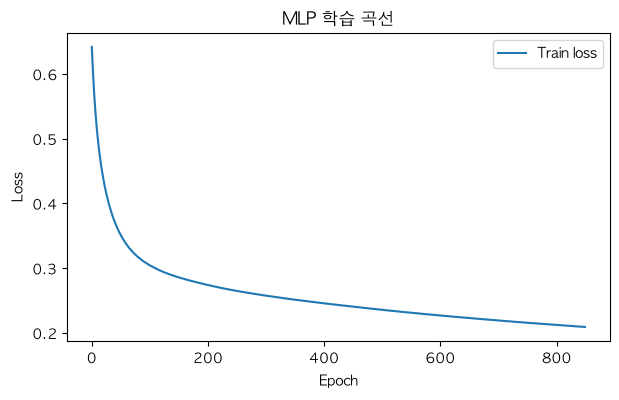

           Train  Validation    Diff
log_loss  0.1978      0.2658 -0.0680
accuracy  0.9216      0.8993  0.0223
auc       0.9706      0.9466  0.0240
f1        0.8590      0.8297  0.0293


In [408]:
n_layers = study_mlp.best_params['n_layers']
hidden_sizes = tuple(study_mlp.best_params[f'n_units_l{i}'] for i in range(n_layers))

final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    random_state=42
)
final_mlp.fit(X_tr_scaled, y_tr)

plt.figure(figsize=(7, 4))
plt.plot(final_mlp.loss_curve_, label='Train loss')
plt.title('MLP 학습 곡선'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()

print(compare_train_val(get_metrics(final_mlp, X_tr_scaled, y_tr), get_metrics(final_mlp, X_val_scaled, y_val)))

In [409]:
!pip install "fastapi[standard]"


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [410]:
import joblib

# MLP 모델 저장
joblib.dump(final_mlp, 'final_mlp_model.pkl')

# 스케일러도 같이 저장 (MLP는 스케일링된 데이터로 학습했으니까 필수!)
joblib.dump(scaler, 'scaler.pkl')

print("모델과 스케일러 저장 완료!")

모델과 스케일러 저장 완료!


In [411]:
print(feature_cols)

['avg_temp', 'min_temp', 'max_temp', 'avg_wind', 'max_wind_dir', 'avg_dewpoint', 'avg_humid', 'avg_pres_sea', 'avg_cloud', 'nino34', 'nino34_lag_days', 'ao_index', 'ao_index_lag_days', 'seaice_extent', 'seaice_extent_lag_days', 'sst_cpac', 'sst_cpac_lag_days', 'sst_npac_mid', 'sst_napc_mid_lag_days', 'sst_natl_north', 'sst_natl_north_lag_days', 'sst_natl_south', 'sst_natl_south_lag_days', 'iod_indian_ocean', 'iod_indian_ocean_lag_days', 'dewpoint_depression', 'temp_range', 'temp_change', 'pres_change', 'wind_change', 'sst_natl_dipole', 'precip_lag1', 'avg_wind_lag1', 'avg_humid_lag1', 'avg_pres_sea_lag1', 'avg_cloud_lag1', 'dewpoint_depression_lag1', 'temp_range_lag1']


In [412]:
import os
print(os.path.exists('final_mlp_model.pkl'))
print(os.path.exists('scaler.pkl'))

True
True


In [413]:
print(df_kma.columns.tolist())

['stn_id', 'stn_name', 'date', 'avg_temp', 'min_temp', 'max_temp', 'precip', 'avg_wind', 'max_wind_dir', 'avg_dewpoint', 'avg_humid', 'avg_pres_sea', 'sum_sunshine', 'avg_cloud', 'precip_occur']


In [414]:
import json

# df_merged에서 가장 최근 행(2026년 7월) 가져오기
latest_row = df_merged.iloc[-1]

# lag_days는 "오늘 - 그 지수 값의 원래 실측 월" 기준으로 다시 계산해야 하는데,
# climatology로 채운 값이라면 lag_days 컬럼 자체도 df_merged에 있을 테니 그대로 가져오면 됨
noaa_cache = {
    "nino34": float(latest_row['nino34']),
    "nino34_lag_days": float(latest_row['nino34_lag_days']),
    "ao_index": float(latest_row['ao_index']),
    "ao_index_lag_days": float(latest_row['ao_index_lag_days']),
    "seaice_extent": float(latest_row['seaice_extent']),
    "seaice_extent_lag_days": float(latest_row['seaice_extent_lag_days']),
    "sst_cpac": float(latest_row['sst_cpac']),
    "sst_cpac_lag_days": float(latest_row['sst_cpac_lag_days']),
    "sst_npac_mid": float(latest_row['sst_npac_mid']),
    "sst_napc_mid_lag_days": float(latest_row['sst_napc_mid_lag_days']),
    "sst_natl_north": float(latest_row['sst_natl_north']),
    "sst_natl_north_lag_days": float(latest_row['sst_natl_north_lag_days']),
    "sst_natl_south": float(latest_row['sst_natl_south']),
    "sst_natl_south_lag_days": float(latest_row['sst_natl_south_lag_days']),
    "iod_indian_ocean": float(latest_row['iod_indian_ocean']),
    "iod_indian_ocean_lag_days": float(latest_row['iod_indian_ocean_lag_days']),
}

with open("noaa_cache.json", "w") as f:
    json.dump(noaa_cache, f, indent=2)

print("noaa_cache.json 저장 완료!")
print(noaa_cache)

noaa_cache.json 저장 완료!
{'nino34': 0.12320388349514563, 'nino34_lag_days': 36.0, 'ao_index': 0.21237540453074433, 'ao_index_lag_days': 218.0, 'seaice_extent': 10.42, 'seaice_extent_lag_days': 36.0, 'sst_cpac': 27.61681553398058, 'sst_cpac_lag_days': 36.0, 'sst_npac_mid': 21.4429, 'sst_napc_mid_lag_days': 36.0, 'sst_natl_north': 18.443, 'sst_natl_north_lag_days': 36.0, 'sst_natl_south': 27.093500000000002, 'sst_natl_south_lag_days': 36.0, 'iod_indian_ocean': 28.2044, 'iod_indian_ocean_lag_days': 36.0}


In [415]:
# 노트북에서
print(df_merged[['date', 'ao_index', 'ao_index_lag_days']].tail(10))

           date  ao_index  ao_index_lag_days
3649 2026-06-28  0.660000                209
3650 2026-06-29  0.660000                210
3651 2026-06-30  0.660000                211
3652 2026-07-01  0.212375                212
3653 2026-07-02  0.212375                213
3654 2026-07-03  0.212375                214
3655 2026-07-04  0.212375                215
3656 2026-07-05  0.212375                216
3657 2026-07-06  0.212375                217
3658 2026-07-07  0.212375                218


In [416]:
# 각 지수마다 값이 바뀌는(climatology로 전환되는) 지점 찾기
for col in ['nino34', 'seaice_extent', 'sst_cpac', 'sst_npac_mid', 
            'sst_natl_north', 'sst_natl_south', 'iod_indian_ocean']:
    print(df_merged[['date', col]].tail(15))
    print("---")

           date    nino34
3644 2026-06-23  0.004444
3645 2026-06-24  0.004444
3646 2026-06-25  0.004444
3647 2026-06-26  0.004444
3648 2026-06-27  0.004444
3649 2026-06-28  0.004444
3650 2026-06-29  0.004444
3651 2026-06-30  0.004444
3652 2026-07-01  0.123204
3653 2026-07-02  0.123204
3654 2026-07-03  0.123204
3655 2026-07-04  0.123204
3656 2026-07-05  0.123204
3657 2026-07-06  0.123204
3658 2026-07-07  0.123204
---
           date  seaice_extent
3644 2026-06-23          12.14
3645 2026-06-24          12.14
3646 2026-06-25          12.14
3647 2026-06-26          12.14
3648 2026-06-27          12.14
3649 2026-06-28          12.14
3650 2026-06-29          12.14
3651 2026-06-30          12.14
3652 2026-07-01          10.42
3653 2026-07-02          10.42
3654 2026-07-03          10.42
3655 2026-07-04          10.42
3656 2026-07-05          10.42
3657 2026-07-06          10.42
3658 2026-07-07          10.42
---
           date   sst_cpac
3644 2026-06-23  27.328333
3645 2026-06-24  27.328333

In [417]:
rolling_cols = [c for c in feature_cols if 'rolling' in c]
print(rolling_cols)

[]


In [418]:
rolling_check = ['humid_rolling_3d_mean', 'pres_rolling_3d_mean', 
                  'precip_rolling_3d_sum', 'precip_rolling_7d_sum']
for col in rolling_check:
    print(col, col in df_merged.columns)

humid_rolling_3d_mean True
pres_rolling_3d_mean True
precip_rolling_3d_sum True
precip_rolling_7d_sum True


In [419]:
# 기존 feature_cols에 rolling 4개 추가
rolling_cols = ['humid_rolling_3d_mean', 'pres_rolling_3d_mean', 
                 'precip_rolling_3d_sum', 'precip_rolling_7d_sum']

feature_cols = feature_cols + rolling_cols

print("새 feature_cols 개수:", len(feature_cols))
print(feature_cols)

새 feature_cols 개수: 42
['avg_temp', 'min_temp', 'max_temp', 'avg_wind', 'max_wind_dir', 'avg_dewpoint', 'avg_humid', 'avg_pres_sea', 'avg_cloud', 'nino34', 'nino34_lag_days', 'ao_index', 'ao_index_lag_days', 'seaice_extent', 'seaice_extent_lag_days', 'sst_cpac', 'sst_cpac_lag_days', 'sst_npac_mid', 'sst_napc_mid_lag_days', 'sst_natl_north', 'sst_natl_north_lag_days', 'sst_natl_south', 'sst_natl_south_lag_days', 'iod_indian_ocean', 'iod_indian_ocean_lag_days', 'dewpoint_depression', 'temp_range', 'temp_change', 'pres_change', 'wind_change', 'sst_natl_dipole', 'precip_lag1', 'avg_wind_lag1', 'avg_humid_lag1', 'avg_pres_sea_lag1', 'avg_cloud_lag1', 'dewpoint_depression_lag1', 'temp_range_lag1', 'humid_rolling_3d_mean', 'pres_rolling_3d_mean', 'precip_rolling_3d_sum', 'precip_rolling_7d_sum']


In [420]:
train = df_merged[df_merged['date'] < '2024-01-01'].copy()
test  = df_merged[df_merged['date'] >= '2024-01-01'].copy()

In [421]:
rolling_cols = ['humid_rolling_3d_mean', 'pres_rolling_3d_mean', 
                 'precip_rolling_3d_sum', 'precip_rolling_7d_sum']

# feature_cols가 이미 41개면 이 줄은 건너뛰어도 됨
if 'humid_rolling_3d_mean' not in feature_cols:
    feature_cols = feature_cols + rolling_cols

print("feature_cols 개수:", len(feature_cols))

feature_cols 개수: 42


In [422]:
print(len(feature_cols))
print(feature_cols)

42
['avg_temp', 'min_temp', 'max_temp', 'avg_wind', 'max_wind_dir', 'avg_dewpoint', 'avg_humid', 'avg_pres_sea', 'avg_cloud', 'nino34', 'nino34_lag_days', 'ao_index', 'ao_index_lag_days', 'seaice_extent', 'seaice_extent_lag_days', 'sst_cpac', 'sst_cpac_lag_days', 'sst_npac_mid', 'sst_napc_mid_lag_days', 'sst_natl_north', 'sst_natl_north_lag_days', 'sst_natl_south', 'sst_natl_south_lag_days', 'iod_indian_ocean', 'iod_indian_ocean_lag_days', 'dewpoint_depression', 'temp_range', 'temp_change', 'pres_change', 'wind_change', 'sst_natl_dipole', 'precip_lag1', 'avg_wind_lag1', 'avg_humid_lag1', 'avg_pres_sea_lag1', 'avg_cloud_lag1', 'dewpoint_depression_lag1', 'temp_range_lag1', 'humid_rolling_3d_mean', 'pres_rolling_3d_mean', 'precip_rolling_3d_sum', 'precip_rolling_7d_sum']


In [423]:
feature_cols = list(dict.fromkeys(feature_cols))  # 순서 유지하면서 중복 제거
print(len(feature_cols))  # 41이 나와야 함

42


In [424]:
# feature_cols 기준으로 NaN 있는 행 제거
train_clean = train.dropna(subset=feature_cols)
test_clean = test.dropna(subset=feature_cols)

X_train = train_clean[feature_cols]
y_train = train_clean[target]
X_test = test_clean[feature_cols]
y_test = test_clean[target]

print("제거 후 X_train shape:", X_train.shape)
print("제거 후 X_test shape:", X_test.shape)

제거 후 X_train shape: (2726, 42)
제거 후 X_test shape: (914, 42)


In [425]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("스케일링 완료")

스케일링 완료


In [426]:
print(len(X_train), len(y_train))
print(len(X_train_scaled), len(y_train))

2726 2726
2726 2726


In [427]:
X_train = train_clean[feature_cols]
y_train = train_clean[target]

In [428]:
X_train = train_clean[feature_cols]
y_train = train_clean[target]
X_test = test_clean[feature_cols]
y_test = test_clean[target]

# 인덱스 리셋 (혹시 인덱스가 안 맞을 수 있으니 안전하게)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(len(X_train), len(y_train))  # 같은 숫자 나와야 함

2726 2726


In [429]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [430]:
# run_cv를 다시 정의 (지금 최신 X_train을 기본값으로 다시 캡처)
def run_cv(model, X_data=None):
    if X_data is None:
        X_data = X_train
    scores = []
    for tr_idx, val_idx in tscv.split(X_data):
        X_tr, X_val = X_data.iloc[tr_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(log_loss(y_val, preds))
    return np.mean(scores)

In [431]:
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }
    return run_cv(xgb.XGBClassifier(**params))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20)
print("XGBoost 완료:", study_xgb.best_value)

[I 2026-07-15 10:42:40,656] A new study created in memory with name: no-name-54d1b55c-9efd-4581-87e2-1f843e407b9e
[I 2026-07-15 10:42:42,179] Trial 0 finished with value: 0.5348281145095826 and parameters: {'learning_rate': 0.47550078371771415, 'max_depth': 3, 'n_estimators': 497, 'subsample': 0.771416050703641, 'colsample_bytree': 0.784702312723574}. Best is trial 0 with value: 0.5348281145095826.
[I 2026-07-15 10:42:45,284] Trial 1 finished with value: 0.3191989541053772 and parameters: {'learning_rate': 0.02485994309204743, 'max_depth': 8, 'n_estimators': 402, 'subsample': 0.7598642856283548, 'colsample_bytree': 0.8800146140929153}. Best is trial 1 with value: 0.3191989541053772.
[I 2026-07-15 10:42:46,493] Trial 2 finished with value: 0.3208043575286865 and parameters: {'learning_rate': 0.05565998763135361, 'max_depth': 6, 'n_estimators': 190, 'subsample': 0.89552069959721, 'colsample_bytree': 0.9479049331277382}. Best is trial 1 with value: 0.3191989541053772.
[I 2026-07-15 10:42:

XGBoost 완료: 0.3017157852649689


In [432]:
def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 0.001, 10, log=True)}
    return run_cv(LogisticRegression(**params, max_iter=1000), X_data=X_train_scaled)

study_logreg = optuna.create_study(direction='minimize')
study_logreg.optimize(objective_logreg, n_trials=20)
print("Logistic Regression 완료:", study_logreg.best_value)

[I 2026-07-15 10:43:20,148] A new study created in memory with name: no-name-3d00966c-b281-4c79-9e7c-1d9a4ee058ca
[I 2026-07-15 10:43:20,165] Trial 0 finished with value: 0.3612004282181385 and parameters: {'C': 0.00441070524076867}. Best is trial 0 with value: 0.3612004282181385.
[I 2026-07-15 10:43:20,177] Trial 1 finished with value: 0.3377498114757234 and parameters: {'C': 0.008709975243401195}. Best is trial 1 with value: 0.3377498114757234.
[I 2026-07-15 10:43:20,188] Trial 2 finished with value: 0.4246202928836156 and parameters: {'C': 0.0012462033924102818}. Best is trial 1 with value: 0.3377498114757234.
[I 2026-07-15 10:43:20,200] Trial 3 finished with value: 0.31658062012779853 and parameters: {'C': 0.02423341552532944}. Best is trial 3 with value: 0.31658062012779853.
[I 2026-07-15 10:43:20,217] Trial 4 finished with value: 0.30764167241634566 and parameters: {'C': 0.30106916513397824}. Best is trial 4 with value: 0.30764167241634566.
[I 2026-07-15 10:43:20,232] Trial 5 fin

Logistic Regression 완료: 0.3070058095877156


In [433]:
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': (
            trial.suggest_int('n_units_1', 16, 128),
            trial.suggest_int('n_units_2', 16, 128),
        ),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'early_stopping': True,
        'n_iter_no_change': 10,
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=20)
print("MLP 완료:", study_mlp.best_value)

[I 2026-07-15 10:43:20,477] A new study created in memory with name: no-name-76d57810-d971-4815-a0e8-0f5cd46bfaf1
[I 2026-07-15 10:43:20,800] Trial 0 finished with value: 0.3292209315384934 and parameters: {'n_units_1': 64, 'n_units_2': 118, 'learning_rate_init': 0.0013908747457491214, 'alpha': 0.000238384028053639}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:43:21,023] Trial 1 finished with value: 0.33466238000304366 and parameters: {'n_units_1': 83, 'n_units_2': 49, 'learning_rate_init': 0.002631390553109184, 'alpha': 0.005690100732049675}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:43:21,239] Trial 2 finished with value: 0.3613043459308224 and parameters: {'n_units_1': 105, 'n_units_2': 84, 'learning_rate_init': 0.021208374902140385, 'alpha': 0.042740103518468915}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:43:21,391] Trial 3 finished with value: 0.33687363800657855 and parameters: {'n_units_1': 16, 'n_units_2': 23, '

MLP 완료: 0.3292209315384934


In [434]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

# MLP만 재조립 필요
hidden_sizes = (
    study_mlp.best_params['n_units_1'],
    study_mlp.best_params['n_units_2']
)
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('log_loss')
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.300556  0.862144  0.930302  0.752941
1  Logistic Regression  0.301698  0.871991  0.926555  0.767396
2                  MLP  0.377192  0.844639  0.885276  0.723735


In [435]:
joblib.dump(final_logreg, 'final_logreg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [436]:
model = joblib.load("final_logreg_model.pkl")   # final_mlp_model.pkl → 이걸로 교체
scaler = joblib.load("scaler.pkl")   # 그대로 유지 (LogReg도 스케일링 필요)

In [437]:
study_xgb.optimize(objective_xgb, n_trials=30)  # 기존 20에 이어서 30번 더 (총 50)
print("XGBoost 갱신된 최고 성능:", study_xgb.best_value)

[I 2026-07-15 10:43:27,059] Trial 20 finished with value: 0.3399887800216675 and parameters: {'learning_rate': 0.13662960249283818, 'max_depth': 5, 'n_estimators': 141, 'subsample': 0.6653231594189892, 'colsample_bytree': 0.6378751112418254}. Best is trial 17 with value: 0.3017157852649689.
[I 2026-07-15 10:43:28,437] Trial 21 finished with value: 0.3056227803230286 and parameters: {'learning_rate': 0.03493718924309249, 'max_depth': 6, 'n_estimators': 211, 'subsample': 0.8229259423442064, 'colsample_bytree': 0.6985786668200856}. Best is trial 17 with value: 0.3017157852649689.
[I 2026-07-15 10:43:29,589] Trial 22 finished with value: 0.3052765429019928 and parameters: {'learning_rate': 0.04160205067938596, 'max_depth': 7, 'n_estimators': 158, 'subsample': 0.7053564459244347, 'colsample_bytree': 0.693733047695737}. Best is trial 17 with value: 0.3017157852649689.
[I 2026-07-15 10:43:30,439] Trial 23 finished with value: 0.30750932097434996 and parameters: {'learning_rate': 0.06223433156

XGBoost 갱신된 최고 성능: 0.3007184565067291


In [438]:
study_logreg.optimize(objective_logreg, n_trials=30)
print("Logistic Regression 최종:", study_logreg.best_value)

# MLP: 20 → 50
study_mlp.optimize(objective_mlp, n_trials=30)
print("MLP 최종:", study_mlp.best_value)

[I 2026-07-15 10:44:11,422] Trial 20 finished with value: 0.30840366685319415 and parameters: {'C': 0.6202612081454599}. Best is trial 13 with value: 0.3070058095877156.
[I 2026-07-15 10:44:11,441] Trial 21 finished with value: 0.30700825778445556 and parameters: {'C': 0.1583147557987355}. Best is trial 13 with value: 0.3070058095877156.
[I 2026-07-15 10:44:11,460] Trial 22 finished with value: 0.3070623374311732 and parameters: {'C': 0.17071252539326714}. Best is trial 13 with value: 0.3070058095877156.
[I 2026-07-15 10:44:11,477] Trial 23 finished with value: 0.30713340697462277 and parameters: {'C': 0.11495302651276804}. Best is trial 13 with value: 0.3070058095877156.
[I 2026-07-15 10:44:11,491] Trial 24 finished with value: 0.3158103112328015 and parameters: {'C': 0.02566668967551818}. Best is trial 13 with value: 0.3070058095877156.
[I 2026-07-15 10:44:11,515] Trial 25 finished with value: 0.30814186784261666 and parameters: {'C': 0.44002775514109055}. Best is trial 13 with value

Logistic Regression 최종: 0.30699058144003616


[I 2026-07-15 10:44:12,188] Trial 20 finished with value: 0.4386685418057298 and parameters: {'n_units_1': 60, 'n_units_2': 111, 'learning_rate_init': 0.0837432302884046, 'alpha': 0.017834275308318256}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:44:12,318] Trial 21 finished with value: 0.33753645909355556 and parameters: {'n_units_1': 23, 'n_units_2': 22, 'learning_rate_init': 0.0036309113249067835, 'alpha': 0.0953335447105546}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:44:12,490] Trial 22 finished with value: 0.35082109006172757 and parameters: {'n_units_1': 17, 'n_units_2': 38, 'learning_rate_init': 0.00529181044886718, 'alpha': 0.005059067152885872}. Best is trial 0 with value: 0.3292209315384934.
[I 2026-07-15 10:44:12,651] Trial 23 finished with value: 0.3447745297745529 and parameters: {'n_units_1': 26, 'n_units_2': 54, 'learning_rate_init': 0.010966954521095886, 'alpha': 0.050227268712721394}. Best is trial 0 with value: 0.32922093153

MLP 최종: 0.3239386937205688


In [439]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('log_loss')
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.298223  0.857768  0.932282  0.747082
1  Logistic Regression  0.301586  0.871991  0.926526  0.767396
2                  MLP  0.454498  0.822757  0.905396  0.730897


In [440]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

print("최종 재학습 완료")

최종 재학습 완료


In [441]:
results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('log_loss')
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.298223  0.857768  0.932282  0.747082
1  Logistic Regression  0.301586  0.871991  0.926526  0.767396
2                  MLP  0.454498  0.822757  0.905396  0.730897


In [442]:
import joblib
joblib.dump(final_logreg, 'final_logreg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("최종 모델 저장 완료!")

최종 모델 저장 완료!


In [443]:
import pandas as pd
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': final_logreg.coef_[0]
}).sort_values('coefficient')
print(coef_df)

                      feature  coefficient
28                pres_change    -0.608654
17               sst_npac_mid    -0.524922
39       pres_rolling_3d_mean    -0.487495
27                temp_change    -0.462541
25        dewpoint_depression    -0.319969
0                    avg_temp    -0.314066
9                      nino34    -0.252961
1                    min_temp    -0.240118
2                    max_temp    -0.235104
4                max_wind_dir    -0.235037
33             avg_humid_lag1    -0.233030
7                avg_pres_sea    -0.187157
30            sst_natl_dipole    -0.180842
5                avg_dewpoint    -0.179657
38      humid_rolling_3d_mean    -0.116866
37            temp_range_lag1    -0.114644
41      precip_rolling_7d_sum    -0.092391
11                   ao_index    -0.077847
23           iod_indian_ocean    -0.067347
21             sst_natl_south    -0.032194
20    sst_natl_north_lag_days     0.003758
16          sst_cpac_lag_days     0.003758
12         

In [444]:
today_values = {
    # ASOS 원본
    'avg_temp': 30.4, 'min_temp': 27.6, 'max_temp': 33.5, 'avg_wind': 2.5,
    'max_wind_dir': 180, 'avg_dewpoint': 22.8, 'avg_humid': 64.6,
    'avg_pres_sea': 999.1, 'avg_cloud': 3.6,
    
    # 파생/변화율
    'dewpoint_depression': 7.6, 'temp_range': 5.9,
    'temp_change': 0.1, 'pres_change': -1.6, 'wind_change': 0.7,
    
    # lag
    'precip_lag1': 0, 'avg_wind_lag1': 1.8, 'avg_humid_lag1': 66.6,
    'avg_pres_sea_lag1': 1000.7, 'avg_cloud_lag1': 2.8,
    'dewpoint_depression_lag1': 7.2, 'temp_range_lag1': 9.8,
    
    # rolling
    'humid_rolling_3d_mean': 68, 'pres_rolling_3d_mean': 1000.4667,
    'precip_rolling_3d_sum': 0, 'precip_rolling_7d_sum': 74,
    
    # NOAA 지수 (noaa_cache.json 값)
    'nino34': 0.123204, 'ao_index': 0.212375, 'seaice_extent': 10.42,
    'sst_cpac': 27.616816, 'sst_npac_mid': 21.4429,
    'sst_natl_north': 18.443, 'sst_natl_south': 27.0935,
    'iod_indian_ocean': 28.2044,
    
    # lag_days (2026-07-14 기준, NOAA_REFERENCE_DATE 2026-06-30로부터 계산)
    'nino34_lag_days': 14, 'ao_index_lag_days': 14, 'seaice_extent_lag_days': 14,
    'sst_cpac_lag_days': 14, 'sst_napc_mid_lag_days': 14,
    'sst_natl_north_lag_days': 14, 'sst_natl_south_lag_days': 14,
    'iod_indian_ocean_lag_days': 14,
    
    # sst_natl_dipole 계산
    'sst_natl_dipole': 27.0935 - 18.443,
}

sample_df = pd.DataFrame([today_values])[feature_cols]
sample_scaled = scaler.transform(sample_df)

print("XGBoost:", final_xgb.predict_proba(sample_df)[:, 1][0])
print("Logistic Regression:", final_logreg.predict_proba(sample_scaled)[:, 1][0])
print("MLP:", final_mlp.predict_proba(sample_scaled)[:, 1][0])

XGBoost: 0.14995293
Logistic Regression: 0.0017940649682163885
MLP: 3.914312969690649e-05


/Users/sojung/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/sojung/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [445]:
# train 데이터프레임에서 date, avg_temp, target(precip_occur)가 
# 같은 행에 있는지 확인
print(train[['date', 'avg_temp', 'avg_humid', 'precip_occur']].head(10))

         date  avg_temp  avg_humid  precip_occur
1  2016-07-02      23.5       81.4             1
2  2016-07-03      23.5       70.4             0
3  2016-07-04      21.8       85.1             1
4  2016-07-05      23.1       93.6             1
5  2016-07-06      22.9       74.0             0
6  2016-07-07      24.0       71.6             0
7  2016-07-08      27.3       66.5             0
8  2016-07-09      27.7       64.8             0
9  2016-07-10      27.9       64.4             0
10 2016-07-11      28.4       67.4             0


In [446]:
# target이 shift(-1) 같은 처리를 거쳤는지 확인
print(df_merged[['date', 'precip_occur']].head(10))
# 그리고 target 변수 자체가 어떻게 정의됐는지
print(target)

         date  precip_occur
1  2016-07-02             1
2  2016-07-03             0
3  2016-07-04             1
4  2016-07-05             1
5  2016-07-06             0
6  2016-07-07             0
7  2016-07-08             0
8  2016-07-09             0
9  2016-07-10             0
10 2016-07-11             0
precip_occur


In [447]:
print(df_kma[df_kma['date'] == '2016-07-02'][['date', 'avg_temp', 'avg_humid', 'precip_occur']])
print(df_merged[df_merged['date'] == '2016-07-02'][['date', 'avg_temp', 'avg_humid', 'precip_occur']])

         date  avg_temp  avg_humid  precip_occur
1  2016-07-02      23.5       81.4             1
        date  avg_temp  avg_humid  precip_occur
1 2016-07-02      23.5       81.4             1


In [448]:
# precip_occur를 하루 앞당겨서 재정의
df_merged['target_next_day'] = df_merged['precip_occur'].shift(-1)

# 확인
print(df_merged[['date', 'avg_temp', 'avg_humid', 'precip_occur', 'target_next_day']].head(10))

         date  avg_temp  avg_humid  precip_occur  target_next_day
1  2016-07-02      23.5       81.4             1              0.0
2  2016-07-03      23.5       70.4             0              1.0
3  2016-07-04      21.8       85.1             1              1.0
4  2016-07-05      23.1       93.6             1              0.0
5  2016-07-06      22.9       74.0             0              0.0
6  2016-07-07      24.0       71.6             0              0.0
7  2016-07-08      27.3       66.5             0              0.0
8  2016-07-09      27.7       64.8             0              0.0
9  2016-07-10      27.9       64.4             0              0.0
10 2016-07-11      28.4       67.4             0              1.0


In [449]:
target = 'target_next_day'

# 마지막 행은 다음날 데이터가 없어서 NaN이 생기니까 제거
df_merged_clean = df_merged.dropna(subset=[target] + feature_cols)

train = df_merged_clean[df_merged_clean['date'] < '2024-01-01'].copy()
test = df_merged_clean[df_merged_clean['date'] >= '2024-01-01'].copy()

X_train = train[feature_cols].reset_index(drop=True)
y_train = train[target].reset_index(drop=True)
X_test = test[feature_cols].reset_index(drop=True)
y_test = test[target].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train 확인:", y_train.value_counts())

X_train shape: (2726, 42)
X_test shape: (913, 42)
y_train 확인: target_next_day
0.0    1929
1.0     797
Name: count, dtype: int64


In [450]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [451]:
# XGBoost
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }
    return run_cv(xgb.XGBClassifier(**params))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)
print("XGBoost 완료:", study_xgb.best_value)

[I 2026-07-15 10:44:19,396] A new study created in memory with name: no-name-beb57df6-6a3a-4329-ad6f-9fc83575e6f0
[I 2026-07-15 10:44:23,327] Trial 0 finished with value: 0.5619969487190246 and parameters: {'learning_rate': 0.027025495336170054, 'max_depth': 10, 'n_estimators': 364, 'subsample': 0.722674753715496, 'colsample_bytree': 0.670467539033105}. Best is trial 0 with value: 0.5619969487190246.
[I 2026-07-15 10:44:27,711] Trial 1 finished with value: 0.6762239217758179 and parameters: {'learning_rate': 0.06508406616230458, 'max_depth': 8, 'n_estimators': 461, 'subsample': 0.7807685733998899, 'colsample_bytree': 0.8237672460502312}. Best is trial 0 with value: 0.5619969487190246.
[I 2026-07-15 10:44:29,307] Trial 2 finished with value: 0.5099663257598877 and parameters: {'learning_rate': 0.01375657847034686, 'max_depth': 4, 'n_estimators': 308, 'subsample': 0.8789575437199081, 'colsample_bytree': 0.9996326658928684}. Best is trial 2 with value: 0.5099663257598877.
[I 2026-07-15 10

XGBoost 완료: 0.5064338982105255


In [452]:
# Logistic Regression
def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 0.001, 10, log=True)}
    return run_cv(LogisticRegression(**params, max_iter=1000), X_data=X_train_scaled)

study_logreg = optuna.create_study(direction='minimize')
study_logreg.optimize(objective_logreg, n_trials=50)
print("Logistic Regression 완료:", study_logreg.best_value)

[I 2026-07-15 10:45:49,135] A new study created in memory with name: no-name-bb7e3c56-4347-43fa-b9cd-a4f137c4d72a
[I 2026-07-15 10:45:49,157] Trial 0 finished with value: 0.5230903348673777 and parameters: {'C': 0.03461202324954424}. Best is trial 0 with value: 0.5230903348673777.
[I 2026-07-15 10:45:49,191] Trial 1 finished with value: 0.5376022870067357 and parameters: {'C': 5.23558256816318}. Best is trial 0 with value: 0.5230903348673777.
[I 2026-07-15 10:45:49,204] Trial 2 finished with value: 0.541582897401744 and parameters: {'C': 0.0023204001235626256}. Best is trial 0 with value: 0.5230903348673777.
[I 2026-07-15 10:45:49,225] Trial 3 finished with value: 0.5283657958624246 and parameters: {'C': 0.25198147479739313}. Best is trial 0 with value: 0.5230903348673777.
[I 2026-07-15 10:45:49,259] Trial 4 finished with value: 0.5382052734585183 and parameters: {'C': 8.674454364589133}. Best is trial 0 with value: 0.5230903348673777.
[I 2026-07-15 10:45:49,277] Trial 5 finished with 

Logistic Regression 완료: 0.5230559639524418


In [453]:
# MLP
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': (
            trial.suggest_int('n_units_1', 16, 128),
            trial.suggest_int('n_units_2', 16, 128),
        ),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'early_stopping': True,
        'n_iter_no_change': 10,
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=50)
print("MLP 완료:", study_mlp.best_value)

[I 2026-07-15 10:45:49,965] A new study created in memory with name: no-name-76870bf9-0fd8-4543-aa76-042e082941f3
[I 2026-07-15 10:45:50,269] Trial 0 finished with value: 0.5965284242295841 and parameters: {'n_units_1': 121, 'n_units_2': 124, 'learning_rate_init': 0.008576186910033414, 'alpha': 0.006203803395940484}. Best is trial 0 with value: 0.5965284242295841.
[I 2026-07-15 10:45:50,504] Trial 1 finished with value: 0.5863581274068963 and parameters: {'n_units_1': 108, 'n_units_2': 72, 'learning_rate_init': 0.0001353875279100934, 'alpha': 0.0002307314678178807}. Best is trial 1 with value: 0.5863581274068963.
[I 2026-07-15 10:45:50,797] Trial 2 finished with value: 0.5643639723647609 and parameters: {'n_units_1': 36, 'n_units_2': 42, 'learning_rate_init': 0.00031892012092180023, 'alpha': 0.03588004694348029}. Best is trial 2 with value: 0.5643639723647609.
[I 2026-07-15 10:45:51,162] Trial 3 finished with value: 0.6218681634830683 and parameters: {'n_units_1': 54, 'n_units_2': 18, 

MLP 완료: 0.5326248231001056


In [454]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

print("최종 재학습 완료")

최종 재학습 완료


In [455]:
results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values('log_loss')
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.523684  0.741512  0.748290  0.391753
1  Logistic Regression  0.534684  0.743702  0.734536  0.434783
2                  MLP  0.648329  0.714129  0.677570  0.374101


In [456]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

print("Dummy log_loss:", log_loss(y_test, dummy_proba))
print("Dummy F1:", f1_score(y_test, dummy.predict(X_test)))

# Persistence: "오늘 비 왔으면 내일도 온다"고 찍기 (즉 오늘의 precip_occur를 그대로 내일 예측값으로)
persistence_pred = test['precip_occur'].values  # 오늘 실제 강수를 그대로 내일 예측으로 사용
persistence_proba = np.clip(persistence_pred.astype(float), 0.001, 0.999)

print("Persistence log_loss:", log_loss(y_test, persistence_proba))
print("Persistence F1:", f1_score(y_test, persistence_pred))

Dummy log_loss: 2.0510887205019928
Dummy F1: 0.0
Persistence log_loss: 2.2023867441306573
Persistence F1: 0.46210720887245843


In [457]:
# y_train, y_test가 진짜 target_next_day 기준으로 만들어졌는지 재확인
print(y_train.name)
print(y_test.name)
print(y_train.head())

target_next_day
target_next_day
0    1.0
1    1.0
2    0.0
3    0.0
4    0.0
Name: target_next_day, dtype: float64


In [458]:
import inspect
print(inspect.getsource(run_cv))

def run_cv(model, X_data=None):
    if X_data is None:
        X_data = X_train
    scores = []
    for tr_idx, val_idx in tscv.split(X_data):
        X_tr, X_val = X_data.iloc[tr_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(log_loss(y_val, preds))
    return np.mean(scores)



In [459]:
persistence_pred = test['precip_occur'].reset_index(drop=True).values
print("Persistence F1 (인덱스 리셋 후):", f1_score(y_test, persistence_pred))

Persistence F1 (인덱스 리셋 후): 0.46210720887245843


In [460]:
df_merged['precip_today'] = df_merged['precip_occur']

feature_cols = feature_cols + ['precip_today']
print("새 feature_cols 개수:", len(feature_cols))

새 feature_cols 개수: 43


In [461]:
df_merged_clean = df_merged.dropna(subset=[target] + feature_cols)

train = df_merged_clean[df_merged_clean['date'] < '2024-01-01'].copy()
test  = df_merged_clean[df_merged_clean['date'] >= '2024-01-01'].copy()

X_train = train[feature_cols].reset_index(drop=True)
y_train = train[target].reset_index(drop=True)
X_test = test[feature_cols].reset_index(drop=True)
y_test = test[target].reset_index(drop=True)

print("X_train shape:", X_train.shape)

X_train shape: (2726, 43)


In [462]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [463]:
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }
    return run_cv(xgb.XGBClassifier(**params))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)
print("XGBoost 완료:", study_xgb.best_value)

[I 2026-07-15 10:46:02,225] A new study created in memory with name: no-name-bd11183e-1a24-4dbb-9e0e-236047109a89
[I 2026-07-15 10:46:03,212] Trial 0 finished with value: 0.5329732418060302 and parameters: {'learning_rate': 0.007038549272184016, 'max_depth': 7, 'n_estimators': 122, 'subsample': 0.9254186802362006, 'colsample_bytree': 0.7165196622847952}. Best is trial 0 with value: 0.5329732418060302.
[I 2026-07-15 10:46:07,283] Trial 1 finished with value: 0.5200279653072357 and parameters: {'learning_rate': 0.010981473124785566, 'max_depth': 10, 'n_estimators': 387, 'subsample': 0.6237729044005873, 'colsample_bytree': 0.9648628435004263}. Best is trial 1 with value: 0.5200279653072357.
[I 2026-07-15 10:46:08,198] Trial 2 finished with value: 0.5138737201690674 and parameters: {'learning_rate': 0.0401346875703227, 'max_depth': 2, 'n_estimators': 336, 'subsample': 0.8435700277679412, 'colsample_bytree': 0.7500693289076473}. Best is trial 2 with value: 0.5138737201690674.
[I 2026-07-15 

XGBoost 완료: 0.50558300614357


In [464]:
def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 0.001, 10, log=True)}
    return run_cv(LogisticRegression(**params, max_iter=1000), X_data=X_train_scaled)

study_logreg = optuna.create_study(direction='minimize')
study_logreg.optimize(objective_logreg, n_trials=50)
print("Logistic Regression 완료:", study_logreg.best_value)

[I 2026-07-15 10:47:10,469] A new study created in memory with name: no-name-fb044adf-3097-4b49-82f8-0bce7e208499
[I 2026-07-15 10:47:10,503] Trial 0 finished with value: 0.5369073876753416 and parameters: {'C': 3.9490214536400163}. Best is trial 0 with value: 0.5369073876753416.
[I 2026-07-15 10:47:10,527] Trial 1 finished with value: 0.5343111360248136 and parameters: {'C': 1.0730335643317102}. Best is trial 1 with value: 0.5343111360248136.
[I 2026-07-15 10:47:10,556] Trial 2 finished with value: 0.5364151226785985 and parameters: {'C': 2.6875145914367606}. Best is trial 1 with value: 0.5343111360248136.
[I 2026-07-15 10:47:10,568] Trial 3 finished with value: 0.5493671323838293 and parameters: {'C': 0.0011760872680083557}. Best is trial 1 with value: 0.5343111360248136.
[I 2026-07-15 10:47:10,583] Trial 4 finished with value: 0.5226713859129737 and parameters: {'C': 0.06915772132400216}. Best is trial 4 with value: 0.5226713859129737.
[I 2026-07-15 10:47:10,604] Trial 5 finished wi

Logistic Regression 완료: 0.5219339693643772


In [465]:
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': (
            trial.suggest_int('n_units_1', 16, 128),
            trial.suggest_int('n_units_2', 16, 128),
        ),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'early_stopping': True,
        'n_iter_no_change': 10,
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=50)
print("MLP 완료:", study_mlp.best_value)

[I 2026-07-15 10:47:11,334] A new study created in memory with name: no-name-33472298-ecf1-483c-bc81-0ad252ddd910
[I 2026-07-15 10:47:11,573] Trial 0 finished with value: 0.5560120414074052 and parameters: {'n_units_1': 47, 'n_units_2': 126, 'learning_rate_init': 0.0004295777879559121, 'alpha': 0.001241192386076258}. Best is trial 0 with value: 0.5560120414074052.
[I 2026-07-15 10:47:11,859] Trial 1 finished with value: 0.5739133638091909 and parameters: {'n_units_1': 66, 'n_units_2': 34, 'learning_rate_init': 0.00013558040654663617, 'alpha': 0.004180445667222211}. Best is trial 0 with value: 0.5560120414074052.
[I 2026-07-15 10:47:12,179] Trial 2 finished with value: 0.5708080193384701 and parameters: {'n_units_1': 97, 'n_units_2': 39, 'learning_rate_init': 0.0013468461360835625, 'alpha': 0.06252113841153951}. Best is trial 0 with value: 0.5560120414074052.
[I 2026-07-15 10:47:12,525] Trial 3 finished with value: 0.5493942323596999 and parameters: {'n_units_1': 119, 'n_units_2': 118, 

MLP 완료: 0.5266041930320138


In [466]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

print("최종 재학습 완료")

최종 재학습 완료


In [467]:
from sklearn.dummy import DummyClassifier
import numpy as np

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

persistence_pred = test['precip_occur'].reset_index(drop=True).values
persistence_proba = np.clip(persistence_pred.astype(float), 0.001, 0.999)

In [468]:
results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results.append({
    'model': 'Dummy',
    'log_loss': log_loss(y_test, dummy_proba),
    'accuracy': accuracy_score(y_test, dummy.predict(X_test)),
    'auc': roc_auc_score(y_test, dummy_proba),
    'f1': f1_score(y_test, dummy.predict(X_test)),
})
results.append({
    'model': 'Persistence',
    'log_loss': log_loss(y_test, persistence_proba),
    'accuracy': accuracy_score(y_test, persistence_pred),
    'auc': roc_auc_score(y_test, persistence_proba),
    'f1': f1_score(y_test, persistence_pred),
})

results_df = pd.DataFrame(results).sort_values('log_loss')
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.522047  0.743702  0.749606  0.400000
1  Logistic Regression  0.533292  0.748083  0.735950  0.452381
2                  MLP  0.631977  0.710843  0.679438  0.359223
3                Dummy  2.051089  0.703176  0.500000  0.000000
4          Persistence  2.202387  0.681271  0.617699  0.462107


In [470]:
from sklearn.metrics import f1_score

xgb_proba = final_xgb.predict_proba(X_test)[:, 1]
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred = (xgb_proba >= threshold).astype(int)
    print(f"threshold={threshold}: F1={f1_score(y_test, pred):.4f}")

threshold=0.3: F1=0.5788
threshold=0.35: F1=0.5257
threshold=0.4: F1=0.4819
threshold=0.45: F1=0.4492
threshold=0.5: F1=0.4000


In [471]:
for threshold in [0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.32]:
    pred = (xgb_proba >= threshold).astype(int)
    print(f"threshold={threshold}: F1={f1_score(y_test, pred):.4f}")

threshold=0.2: F1=0.5637
threshold=0.22: F1=0.5625
threshold=0.24: F1=0.5586
threshold=0.26: F1=0.5653
threshold=0.28: F1=0.5779
threshold=0.3: F1=0.5788
threshold=0.32: F1=0.5690


In [472]:
# Logistic Regression
logreg_proba = final_logreg.predict_proba(X_test_scaled)[:, 1]
for threshold in [0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32]:
    pred = (logreg_proba >= threshold).astype(int)
    print(f"LogReg threshold={threshold}: F1={f1_score(y_test, pred):.4f}")

LogReg threshold=0.2: F1=0.5446
LogReg threshold=0.22: F1=0.5398
LogReg threshold=0.24: F1=0.5437
LogReg threshold=0.26: F1=0.5377
LogReg threshold=0.28: F1=0.5319
LogReg threshold=0.3: F1=0.5306
LogReg threshold=0.32: F1=0.5333


In [473]:
# MLP
mlp_proba = final_mlp.predict_proba(X_test_scaled)[:, 1]
for threshold in [0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32]:
    pred = (mlp_proba >= threshold).astype(int)
    print(f"MLP threshold={threshold}: F1={f1_score(y_test, pred):.4f}")

MLP threshold=0.2: F1=0.5303
MLP threshold=0.22: F1=0.5225
MLP threshold=0.24: F1=0.5156
MLP threshold=0.26: F1=0.5162
MLP threshold=0.28: F1=0.5076
MLP threshold=0.3: F1=0.4991
MLP threshold=0.32: F1=0.5054


In [474]:
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score
import pandas as pd
import numpy as np

# 각 모델의 확률 예측값
xgb_proba = final_xgb.predict_proba(X_test)[:, 1]
logreg_proba = final_logreg.predict_proba(X_test_scaled)[:, 1]
mlp_proba = final_mlp.predict_proba(X_test_scaled)[:, 1]

# 각 모델별 최적 threshold (앞서 찾은 값)
thresholds = {
    'XGBoost': 0.26,
    'Logistic Regression': 0.24,
    'MLP': 0.20,
}

probas = {
    'XGBoost': xgb_proba,
    'Logistic Regression': logreg_proba,
    'MLP': mlp_proba,
}

results = []
for name, proba in probas.items():
    threshold = thresholds[name]
    pred = (proba >= threshold).astype(int)
    results.append({
        'model': name,
        'threshold': threshold,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

# Dummy, Persistence (threshold 개념 없음, 기존 값 그대로)
results.append({
    'model': 'Dummy',
    'threshold': '-',
    'log_loss': log_loss(y_test, dummy_proba),
    'accuracy': accuracy_score(y_test, dummy.predict(X_test)),
    'auc': roc_auc_score(y_test, dummy_proba),
    'f1': f1_score(y_test, dummy.predict(X_test)),
})
results.append({
    'model': 'Persistence',
    'threshold': '-',
    'log_loss': log_loss(y_test, persistence_proba),
    'accuracy': accuracy_score(y_test, persistence_pred),
    'auc': roc_auc_score(y_test, persistence_proba),
    'f1': f1_score(y_test, persistence_pred),
})

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
print(results_df)

                 model threshold  log_loss  accuracy       auc        f1
0              XGBoost      0.26  0.522047  0.668127  0.749606  0.565280
1  Logistic Regression      0.24  0.533292  0.634173  0.735950  0.543716
2                  MLP       0.2  0.631977  0.642935  0.679438  0.530259
3          Persistence         -  2.202387  0.681271  0.617699  0.462107
4                Dummy         -  2.051089  0.703176  0.500000  0.000000


In [475]:
import joblib
joblib.dump(final_xgb, 'final_xgb_model.pkl')
print("저장 완료!")

저장 완료!


In [476]:
import os
print(os.path.exists('final_xgb_model.pkl'))

True


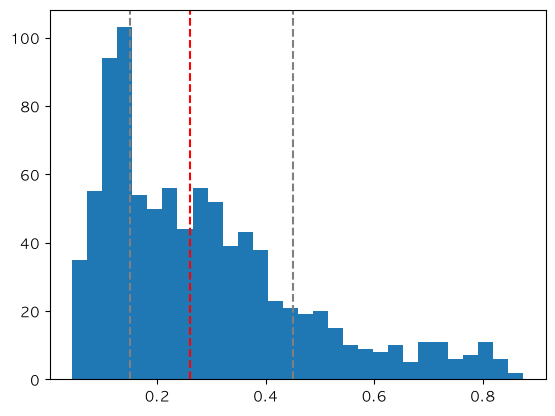

In [477]:
import matplotlib.pyplot as plt
plt.hist(xgb_proba, bins=30)
plt.axvline(0.15, color='gray', linestyle='--')
plt.axvline(0.26, color='red', linestyle='--')
plt.axvline(0.45, color='gray', linestyle='--')
plt.show()

In [478]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score
import numpy as np
import pandas as pd

# Dummy
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

# Persistence — "오늘(기준일) 강수가 그대로 내일도 이어진다"
persistence_pred = test['precip_occur'].reset_index(drop=True).values
persistence_proba = np.clip(persistence_pred.astype(float), 0.001, 0.999)

results = []

# 세 모델 (threshold=0.5 기본값)
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

# Dummy
results.append({
    'model': 'Dummy',
    'log_loss': log_loss(y_test, dummy_proba),
    'accuracy': accuracy_score(y_test, dummy.predict(X_test)),
    'auc': roc_auc_score(y_test, dummy_proba),
    'f1': f1_score(y_test, dummy.predict(X_test)),
})

# Persistence
results.append({
    'model': 'Persistence',
    'log_loss': log_loss(y_test, persistence_proba),
    'accuracy': accuracy_score(y_test, persistence_pred),
    'auc': roc_auc_score(y_test, persistence_proba),
    'f1': f1_score(y_test, persistence_pred),
})

results_df = pd.DataFrame(results).sort_values('log_loss').reset_index(drop=True)
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.522047  0.743702  0.749606  0.400000
1  Logistic Regression  0.533292  0.748083  0.735950  0.452381
2                  MLP  0.631977  0.710843  0.679438  0.359223
3                Dummy  2.051089  0.703176  0.500000  0.000000
4          Persistence  2.202387  0.681271  0.617699  0.462107


In [479]:
import numpy as np

df_merged['month'] = pd.to_datetime(df_merged['date']).dt.month
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12)

print(df_merged[['date', 'month', 'month_sin', 'month_cos']].head(10))

         date  month  month_sin  month_cos
1  2016-07-02      7       -0.5  -0.866025
2  2016-07-03      7       -0.5  -0.866025
3  2016-07-04      7       -0.5  -0.866025
4  2016-07-05      7       -0.5  -0.866025
5  2016-07-06      7       -0.5  -0.866025
6  2016-07-07      7       -0.5  -0.866025
7  2016-07-08      7       -0.5  -0.866025
8  2016-07-09      7       -0.5  -0.866025
9  2016-07-10      7       -0.5  -0.866025
10 2016-07-11      7       -0.5  -0.866025


In [480]:
feature_cols = feature_cols + ['month_sin', 'month_cos']
print("새 feature_cols 개수:", len(feature_cols))

새 feature_cols 개수: 45


In [481]:
df_merged_clean = df_merged.dropna(subset=[target] + feature_cols)

train = df_merged_clean[df_merged_clean['date'] < '2024-01-01'].copy()
test = df_merged_clean[df_merged_clean['date'] >= '2024-01-01'].copy()

X_train = train[feature_cols].reset_index(drop=True)
y_train = train[target].reset_index(drop=True)
X_test = test[feature_cols].reset_index(drop=True)
y_test = test[target].reset_index(drop=True)

print("X_train shape:", X_train.shape)

X_train shape: (2726, 45)


In [482]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [483]:
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }
    return run_cv(xgb.XGBClassifier(**params))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)
print("XGBoost 완료:", study_xgb.best_value)

[I 2026-07-15 10:47:25,405] A new study created in memory with name: no-name-3b9344d9-bc13-4bc5-a3c7-fa629af9a607
[I 2026-07-15 10:47:27,630] Trial 0 finished with value: 0.6975931882858276 and parameters: {'learning_rate': 0.12270333350619031, 'max_depth': 6, 'n_estimators': 333, 'subsample': 0.7087952850313322, 'colsample_bytree': 0.7117144439154007}. Best is trial 0 with value: 0.6975931882858276.
[I 2026-07-15 10:47:28,522] Trial 1 finished with value: 0.5322393417358399 and parameters: {'learning_rate': 0.007816130664072048, 'max_depth': 7, 'n_estimators': 104, 'subsample': 0.8740937400157508, 'colsample_bytree': 0.9211140226738185}. Best is trial 1 with value: 0.5322393417358399.
[I 2026-07-15 10:47:30,356] Trial 2 finished with value: 0.5725977480411529 and parameters: {'learning_rate': 0.04927087841708794, 'max_depth': 7, 'n_estimators': 233, 'subsample': 0.773004452113086, 'colsample_bytree': 0.9678826084873597}. Best is trial 1 with value: 0.5322393417358399.
[I 2026-07-15 10

XGBoost 완료: 0.50664724111557


In [484]:
def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 0.001, 10, log=True)}
    return run_cv(LogisticRegression(**params, max_iter=1000), X_data=X_train_scaled)

study_logreg = optuna.create_study(direction='minimize')
study_logreg.optimize(objective_logreg, n_trials=50)
print("Logistic Regression 완료:", study_logreg.best_value)

[I 2026-07-15 10:48:43,933] A new study created in memory with name: no-name-f01c7d80-9913-4cf4-80c5-ebc6799f605a
[I 2026-07-15 10:48:43,953] Trial 0 finished with value: 0.5244746437774435 and parameters: {'C': 0.012027508472333222}. Best is trial 0 with value: 0.5244746437774435.
[I 2026-07-15 10:48:43,985] Trial 1 finished with value: 0.5382516045218658 and parameters: {'C': 3.4260778536978442}. Best is trial 0 with value: 0.5244746437774435.
[I 2026-07-15 10:48:43,998] Trial 2 finished with value: 0.5446266419081665 and parameters: {'C': 0.0016109791821907794}. Best is trial 0 with value: 0.5244746437774435.
[I 2026-07-15 10:48:44,016] Trial 3 finished with value: 0.5234864717880563 and parameters: {'C': 0.08779615993869166}. Best is trial 3 with value: 0.5234864717880563.
[I 2026-07-15 10:48:44,030] Trial 4 finished with value: 0.5254781779629568 and parameters: {'C': 0.009980218333830263}. Best is trial 3 with value: 0.5234864717880563.
[I 2026-07-15 10:48:44,043] Trial 5 finishe

Logistic Regression 완료: 0.5219920769482593


In [485]:
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': (
            trial.suggest_int('n_units_1', 16, 128),
            trial.suggest_int('n_units_2', 16, 128),
        ),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'early_stopping': True,
        'n_iter_no_change': 10,
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(objective_mlp, n_trials=50)
print("MLP 완료:", study_mlp.best_value)

[I 2026-07-15 10:48:44,774] A new study created in memory with name: no-name-c21468f8-b1ce-4abf-9199-5a1ed831180e
[I 2026-07-15 10:48:45,010] Trial 0 finished with value: 0.5452206922699961 and parameters: {'n_units_1': 108, 'n_units_2': 119, 'learning_rate_init': 0.02646289527902131, 'alpha': 0.038656823855613816}. Best is trial 0 with value: 0.5452206922699961.
[I 2026-07-15 10:48:45,153] Trial 1 finished with value: 0.5411562913365452 and parameters: {'n_units_1': 54, 'n_units_2': 36, 'learning_rate_init': 0.003626511470909262, 'alpha': 0.00018333846062757022}. Best is trial 1 with value: 0.5411562913365452.
[I 2026-07-15 10:48:45,353] Trial 2 finished with value: 0.5400878180788858 and parameters: {'n_units_1': 127, 'n_units_2': 46, 'learning_rate_init': 0.011508267913412208, 'alpha': 0.030330365076762185}. Best is trial 2 with value: 0.5400878180788858.
[I 2026-07-15 10:48:45,556] Trial 3 finished with value: 0.5501854124377016 and parameters: {'n_units_1': 93, 'n_units_2': 60, 'l

MLP 완료: 0.5288005036784407


In [486]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

print("최종 재학습 완료")

최종 재학습 완료


In [487]:
from sklearn.dummy import DummyClassifier
import numpy as np

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

persistence_pred = test['precip_occur'].reset_index(drop=True).values
persistence_proba = np.clip(persistence_pred.astype(float), 0.001, 0.999)

In [488]:
results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results.append({
    'model': 'Dummy',
    'log_loss': log_loss(y_test, dummy_proba),
    'accuracy': accuracy_score(y_test, dummy.predict(X_test)),
    'auc': roc_auc_score(y_test, dummy_proba),
    'f1': f1_score(y_test, dummy.predict(X_test)),
})
results.append({
    'model': 'Persistence',
    'log_loss': log_loss(y_test, persistence_proba),
    'accuracy': accuracy_score(y_test, persistence_pred),
    'auc': roc_auc_score(y_test, persistence_proba),
    'f1': f1_score(y_test, persistence_pred),
})

results_df = pd.DataFrame(results).sort_values('log_loss').reset_index(drop=True)
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.522866  0.745893  0.749721  0.389474
1  Logistic Regression  0.532829  0.748083  0.736433  0.452381
2                  MLP  0.557667  0.730559  0.710194  0.411483
3                Dummy  2.051089  0.703176  0.500000  0.000000
4          Persistence  2.202387  0.681271  0.617699  0.462107


In [489]:
df_merged['humid_rolling_5d_mean'] = df_merged['avg_humid'].rolling(5).mean()
df_merged['pres_rolling_5d_mean'] = df_merged['avg_pres_sea'].rolling(5).mean()
df_merged['precip_rolling_14d_sum'] = df_merged['precip'].rolling(14).sum()

feature_cols = feature_cols + ['humid_rolling_5d_mean', 'pres_rolling_5d_mean', 'precip_rolling_14d_sum']

In [490]:
df_merged['humid_pres_interaction'] = df_merged['avg_humid'] * (1013 - df_merged['avg_pres_sea'])
# 습도 높고 기압 낮을수록 값이 커짐 → "위험 신호"를 하나의 숫자로 압축

feature_cols = feature_cols + ['humid_pres_interaction']

In [491]:
df_merged['pres_change_lag1'] = df_merged['pres_change'].shift(1)
df_merged['pres_acceleration'] = df_merged['pres_change'] - df_merged['pres_change_lag1']
# 기압이 "점점 더 빠르게" 떨어지고 있는지 포착

feature_cols = feature_cols + ['pres_acceleration']

In [492]:
df_merged['humid_rolling_5d_mean'] = df_merged['avg_humid'].rolling(5).mean()
df_merged['pres_rolling_5d_mean'] = df_merged['avg_pres_sea'].rolling(5).mean()
df_merged['precip_rolling_14d_sum'] = df_merged['precip'].rolling(14).sum()
df_merged['humid_pres_interaction'] = df_merged['avg_humid'] * (1013 - df_merged['avg_pres_sea'])

feature_cols = feature_cols + [
    'humid_rolling_5d_mean', 'pres_rolling_5d_mean', 
    'precip_rolling_14d_sum', 'humid_pres_interaction'
]

print("새 feature_cols 개수:", len(feature_cols))

새 feature_cols 개수: 54


In [493]:
from collections import Counter
counts = Counter(feature_cols)
duplicates = [item for item, count in counts.items() if count > 1]
print("중복된 컬럼:", duplicates)
print(len(feature_cols))

중복된 컬럼: ['humid_rolling_5d_mean', 'pres_rolling_5d_mean', 'precip_rolling_14d_sum', 'humid_pres_interaction']
54


In [494]:
feature_cols = list(dict.fromkeys(feature_cols))
print(len(feature_cols))

50


In [495]:
print(feature_cols)

['avg_temp', 'min_temp', 'max_temp', 'avg_wind', 'max_wind_dir', 'avg_dewpoint', 'avg_humid', 'avg_pres_sea', 'avg_cloud', 'nino34', 'nino34_lag_days', 'ao_index', 'ao_index_lag_days', 'seaice_extent', 'seaice_extent_lag_days', 'sst_cpac', 'sst_cpac_lag_days', 'sst_npac_mid', 'sst_napc_mid_lag_days', 'sst_natl_north', 'sst_natl_north_lag_days', 'sst_natl_south', 'sst_natl_south_lag_days', 'iod_indian_ocean', 'iod_indian_ocean_lag_days', 'dewpoint_depression', 'temp_range', 'temp_change', 'pres_change', 'wind_change', 'sst_natl_dipole', 'precip_lag1', 'avg_wind_lag1', 'avg_humid_lag1', 'avg_pres_sea_lag1', 'avg_cloud_lag1', 'dewpoint_depression_lag1', 'temp_range_lag1', 'humid_rolling_3d_mean', 'pres_rolling_3d_mean', 'precip_rolling_3d_sum', 'precip_rolling_7d_sum', 'precip_today', 'month_sin', 'month_cos', 'humid_rolling_5d_mean', 'pres_rolling_5d_mean', 'precip_rolling_14d_sum', 'humid_pres_interaction', 'pres_acceleration']


In [496]:
print('pres_acceleration' in df_merged.columns)
print(df_merged[['date', 'pres_change', 'pres_acceleration']].head(10))

True
         date  pres_change  pres_acceleration
1  2016-07-02          0.5                NaN
2  2016-07-03          4.6                4.1
3  2016-07-04         -0.1               -4.7
4  2016-07-05          0.2                0.3
5  2016-07-06          4.3                4.1
6  2016-07-07          0.5               -3.8
7  2016-07-08         -4.6               -5.1
8  2016-07-09         -3.6                1.0
9  2016-07-10         -1.7                1.9
10 2016-07-11         -0.8                0.9


In [497]:
from collections import Counter
counts = Counter(feature_cols)
duplicates = [item for item, count in counts.items() if count > 1]
print("중복된 컬럼:", duplicates)
print(len(feature_cols))

중복된 컬럼: []
50


In [498]:
df_merged_clean = df_merged.dropna(subset=[target] + feature_cols)

train = df_merged_clean[df_merged_clean['date'] < '2024-01-01'].copy()
test = df_merged_clean[df_merged_clean['date'] >= '2024-01-01'].copy()

X_train = train[feature_cols].reset_index(drop=True)
y_train = train[target].reset_index(drop=True)
X_test = test[feature_cols].reset_index(drop=True)
y_test = test[target].reset_index(drop=True)

print("X_train shape:", X_train.shape)

X_train shape: (2714, 50)


In [499]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [500]:
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42
    }
    return run_cv(xgb.XGBClassifier(**params))

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50)
print("XGBoost 완료:", study_xgb.best_value)

[I 2026-07-15 10:48:57,495] A new study created in memory with name: no-name-a5a0accd-48c2-4d51-bd75-7da82aa63850
[I 2026-07-15 10:49:01,824] Trial 0 finished with value: 0.5230853915214538 and parameters: {'learning_rate': 0.010253509690168486, 'max_depth': 10, 'n_estimators': 393, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.5230853915214538.
[I 2026-07-15 10:49:03,034] Trial 1 finished with value: 0.5282794952392578 and parameters: {'learning_rate': 0.0026364803038431655, 'max_depth': 2, 'n_estimators': 447, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184182}. Best is trial 0 with value: 0.5230853915214538.
[I 2026-07-15 10:49:07,793] Trial 2 finished with value: 0.5527421236038208 and parameters: {'learning_rate': 0.001136467270001117, 'max_depth': 10, 'n_estimators': 433, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}. Best is trial 0 with value: 0.5230853915214538.
[I 2026-07

XGBoost 완료: 0.5058947622776031


In [501]:
def objective_logreg(trial):
    params = {'C': trial.suggest_float('C', 0.001, 10, log=True)}
    return run_cv(LogisticRegression(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_logreg = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_logreg.optimize(objective_logreg, n_trials=50)
print("Logistic Regression 완료:", study_logreg.best_value)

[I 2026-07-15 10:50:16,906] A new study created in memory with name: no-name-eea47451-5acf-4390-a02f-1a00197f8cf8
[I 2026-07-15 10:50:16,927] Trial 0 finished with value: 0.5211459834267054 and parameters: {'C': 0.03148911647956861}. Best is trial 0 with value: 0.5211459834267054.
[I 2026-07-15 10:50:16,962] Trial 1 finished with value: 0.5419294672393367 and parameters: {'C': 6.3512210106407005}. Best is trial 0 with value: 0.5211459834267054.
[I 2026-07-15 10:50:16,989] Trial 2 finished with value: 0.5311855700132143 and parameters: {'C': 0.847180141881998}. Best is trial 0 with value: 0.5211459834267054.
[I 2026-07-15 10:50:17,010] Trial 3 finished with value: 0.5255898044847778 and parameters: {'C': 0.24810409748678114}. Best is trial 0 with value: 0.5211459834267054.
[I 2026-07-15 10:50:17,022] Trial 4 finished with value: 0.5312634641474697 and parameters: {'C': 0.004207988669606638}. Best is trial 0 with value: 0.5211459834267054.
[I 2026-07-15 10:50:17,035] Trial 5 finished wit

Logistic Regression 완료: 0.5210200383552925


In [502]:
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': (
            trial.suggest_int('n_units_1', 16, 128),
            trial.suggest_int('n_units_2', 16, 128),
        ),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 0.0001, 0.1, log=True),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'early_stopping': True,
        'n_iter_no_change': 10,
    }
    return run_cv(MLPClassifier(**params, max_iter=1000, random_state=42), X_data=X_train_scaled)

study_mlp = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_mlp.optimize(objective_mlp, n_trials=50)
print("MLP 완료:", study_mlp.best_value)

[I 2026-07-15 10:50:17,858] A new study created in memory with name: no-name-b5e2f16e-6c42-4bf0-978a-64bdbe81e32c
[I 2026-07-15 10:50:18,040] Trial 0 finished with value: 0.5390263116704791 and parameters: {'n_units_1': 58, 'n_units_2': 123, 'learning_rate_init': 0.015702970884055395, 'alpha': 0.006251373574521752}. Best is trial 0 with value: 0.5390263116704791.
[I 2026-07-15 10:50:18,250] Trial 1 finished with value: 0.6144600629060842 and parameters: {'n_units_1': 33, 'n_units_2': 33, 'learning_rate_init': 0.00014936568554617635, 'alpha': 0.0396760507705299}. Best is trial 0 with value: 0.5390263116704791.
[I 2026-07-15 10:50:18,619] Trial 2 finished with value: 0.5949541962593585 and parameters: {'n_units_1': 83, 'n_units_2': 96, 'learning_rate_init': 0.00011527987128232407, 'alpha': 0.0812324508558869}. Best is trial 0 with value: 0.5390263116704791.
[I 2026-07-15 10:50:18,884] Trial 3 finished with value: 0.5774283982644159 and parameters: {'n_units_1': 110, 'n_units_2': 39, 'lea

MLP 완료: 0.5320506574204363


In [503]:
final_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='binary:logistic', eval_metric='logloss')
final_xgb.fit(X_train, y_train)

final_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
final_logreg.fit(X_train_scaled, y_train)

hidden_sizes = (study_mlp.best_params['n_units_1'], study_mlp.best_params['n_units_2'])
final_mlp = MLPClassifier(
    hidden_layer_sizes=hidden_sizes,
    learning_rate_init=study_mlp.best_params['learning_rate_init'],
    alpha=study_mlp.best_params['alpha'],
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)
final_mlp.fit(X_train_scaled, y_train)

print("최종 재학습 완료")

최종 재학습 완료


In [504]:
from sklearn.dummy import DummyClassifier
import numpy as np

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_proba = np.clip(dummy.predict_proba(X_test)[:, 1], 0.001, 0.999)

persistence_pred = test['precip_occur'].reset_index(drop=True).values
persistence_proba = np.clip(persistence_pred.astype(float), 0.001, 0.999)

In [505]:
results = []
for name, model, X_te in [
    ('XGBoost', final_xgb, X_test),
    ('Logistic Regression', final_logreg, X_test_scaled),
    ('MLP', final_mlp, X_test_scaled),
]:
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    results.append({
        'model': name,
        'log_loss': log_loss(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'f1': f1_score(y_test, pred),
    })

results.append({
    'model': 'Dummy',
    'log_loss': log_loss(y_test, dummy_proba),
    'accuracy': accuracy_score(y_test, dummy.predict(X_test)),
    'auc': roc_auc_score(y_test, dummy_proba),
    'f1': f1_score(y_test, dummy.predict(X_test)),
})
results.append({
    'model': 'Persistence',
    'log_loss': log_loss(y_test, persistence_proba),
    'accuracy': accuracy_score(y_test, persistence_pred),
    'auc': roc_auc_score(y_test, persistence_proba),
    'f1': f1_score(y_test, persistence_pred),
})

results_df = pd.DataFrame(results).sort_values('log_loss').reset_index(drop=True)
print(results_df)

                 model  log_loss  accuracy       auc        f1
0              XGBoost  0.520474  0.749179  0.752882  0.417303
1  Logistic Regression  0.533875  0.739321  0.734519  0.419512
2                  MLP  0.574221  0.728368  0.700664  0.423256
3                Dummy  2.051089  0.703176  0.500000  0.000000
4          Persistence  2.202387  0.681271  0.617699  0.462107
